# RFP 문서 EDA (탐색적 데이터 분석)
**목적**: RAG 시스템 구축을 위한 데이터 이해  
**데이터**: `data_list.csv` (메타데이터 + 텍스트) + `files/` (원본 문서 101개)

In [27]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import re
import unicodedata
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['font.family'] = 'AppleGothic'
plt.rcParams['axes.unicode_minus'] = False
plt.style.use('seaborn-v0_8-whitegrid')

df = pd.read_csv('data_list.csv')
print(f'행: {len(df)}, 열: {len(df.columns)}')
print(f'\n컬럼: {list(df.columns)}')
df.head(3)

행: 100, 열: 12

컬럼: ['공고 번호', '공고 차수', '사업명', '사업 금액', '발주 기관', '공개 일자', '입찰 참여 시작일', '입찰 참여 마감일', '사업 요약', '파일형식', '파일명', '텍스트']


,공고 번호,공고 차수,사업명,사업 금액,발주 기관,공개 일자,입찰 참여 시작일,입찰 참여 마감일,사업 요약,파일형식,파일명,텍스트
0,20241001798,0.0,한영대학교 특성화 맞춤형 교육환경 구축 - 트랙운영 학사정보시스템 고도화,130000000.0,한영대학,2024-10-04 13:51:23,NaN,2024-10-15 17:00:00,- 한영대학교 특성화 맞춤형 교육환경 구축을 위해 트랙운영 학사정보시스템을 고도화한...,hwp,한영대학_한영대학교 특성화 맞춤형 교육환경 구축 - 트랙운영 학사정보.hwp,\n \n2024년 특성화 맞춤형 교육환경 구축 – 트랙운영 학사정보시스템 ...
1,20241002912,0.0,2024년 대학산학협력활동 실태조사 시스템(UICC) 기능개선,129300000.0,한국연구재단,2024-10-04 15:01:52,2024-10-14 10:00:00,2024-10-16 14:00:00,- 사업 개요: 2024년 대학 산학협력활동 실태조사 시스템(UICC) 기능개선\n...,hwp,한국연구재단_2024년 대학산학협력활동 실태조사 시스템(UICC) 기능개선.hwp,\r\n \r\n \r\n \r\n제 안 요 청 서\r\n[ 2024년 대학 ...
2,20240827859,0.0,EIP3.0 고압가스 안전관리 시스템 구축 용역,40000000.0,한국생산기술연구원,2024-08-28 11:31:02,2024-08-29 09:00:00,2024-09-09 10:00:00,- 사업 개요: EIP3.0 고압가스 안전관리 시스템 구축 용역\n- 추진배경: 안...,hwp,한국생산기술연구원_EIP3.0 고압가스 안전관리 시스템 구축 용역.hwp,\r\n \r\nEIP3.0 고압가스 안전관리\r\n시스템 구축 용역\...


## 1. 기본 정보 및 결측치

In [28]:
print('=== 데이터 타입 ===')
print(df.dtypes)
print(f'\n=== 결측치 ===')
print(df.isnull().sum())
print(f'\n=== 결측치 비율(%) ===')
print((df.isnull().sum() / len(df) * 100).round(2))

=== 데이터 타입 ===
공고 번호         object
공고 차수        float64
사업명           object
사업 금액        float64
발주 기관         object
공개 일자         object
입찰 참여 시작일     object
입찰 참여 마감일     object
사업 요약         object
파일형식          object
파일명           object
텍스트           object
dtype: object

=== 결측치 ===
공고 번호        18
공고 차수        18
사업명           0
사업 금액         1
발주 기관         0
공개 일자         0
입찰 참여 시작일    26
입찰 참여 마감일     8
사업 요약         0
파일형식          0
파일명           0
텍스트           0
dtype: int64

=== 결측치 비율(%) ===
공고 번호        18.0
공고 차수        18.0
사업명           0.0
사업 금액         1.0
발주 기관         0.0
공개 일자         0.0
입찰 참여 시작일    26.0
입찰 참여 마감일     8.0
사업 요약         0.0
파일형식          0.0
파일명           0.0
텍스트           0.0
dtype: float64


In [29]:
# 중복 확인
print(f'전체 행: {len(df)}')
print(f'공고 번호 고유값: {df["공고 번호"].nunique()}')
print(f'파일명 고유값: {df["파일명"].nunique()}')
print(f'완전 중복 행: {df.duplicated().sum()}')

전체 행: 100
공고 번호 고유값: 82
파일명 고유값: 100
완전 중복 행: 0


## 2. 메타데이터 분포

=== 파일형식 ===
파일형식
hwp    96
pdf     4
Name: count, dtype: int64


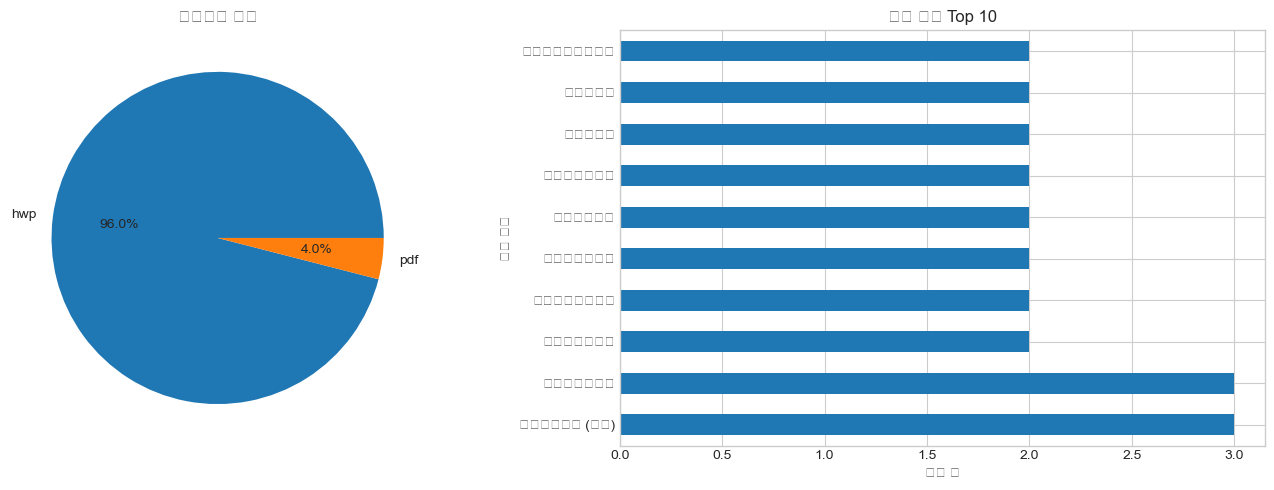


발주 기관 총 87개


In [30]:
# 파일형식 분포
print('=== 파일형식 ===')
print(df['파일형식'].value_counts())

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 파일형식 파이차트
df['파일형식'].value_counts().plot.pie(ax=axes[0], autopct='%1.1f%%')
axes[0].set_title('파일형식 분포')
axes[0].set_ylabel('')

# 발주기관 Top 10
df['발주 기관'].value_counts().head(10).plot.barh(ax=axes[1])
axes[1].set_title('발주 기관 Top 10')
axes[1].set_xlabel('문서 수')

plt.tight_layout()
plt.show()

print(f'\n발주 기관 총 {df["발주 기관"].nunique()}개')

=== 사업 금액 통계 ===
count    9.900000e+01
mean     6.906720e+08
std      1.966691e+09
min      0.000000e+00
25%      7.000000e+07
50%      1.727000e+08
75%      4.064889e+08
max      1.410701e+10
Name: 사업 금액, dtype: float64


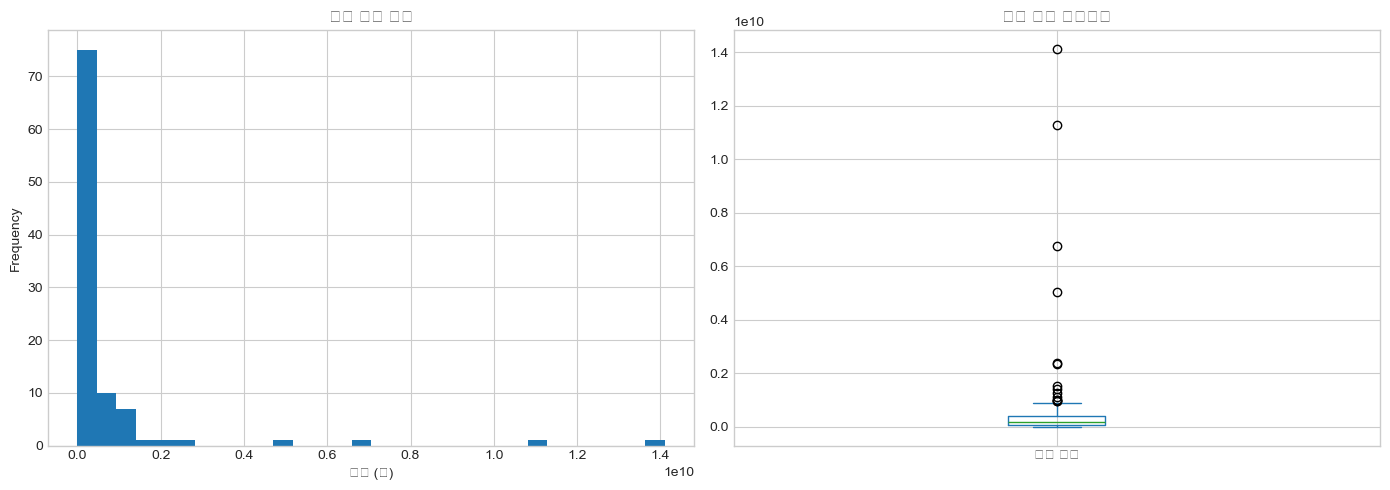


=== 금액 구간별 분포 ===
금액구간
1억 미만     31
1~5억      41
5~10억     11
10~50억     6
50억 이상     4
Name: count, dtype: int64


In [31]:
# 사업 금액 분포
print('=== 사업 금액 통계 ===')
print(df['사업 금액'].describe())

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

df['사업 금액'].dropna().plot.hist(bins=30, ax=axes[0])
axes[0].set_title('사업 금액 분포')
axes[0].set_xlabel('금액 (원)')

df['사업 금액'].dropna().plot.box(ax=axes[1])
axes[1].set_title('사업 금액 박스플롯')

plt.tight_layout()
plt.show()

# 금액 구간별
bins = [0, 1e8, 5e8, 1e9, 5e9, float('inf')]
labels = ['1억 미만', '1~5억', '5~10억', '10~50억', '50억 이상']
df['금액구간'] = pd.cut(df['사업 금액'], bins=bins, labels=labels)
print('\n=== 금액 구간별 분포 ===')
print(df['금액구간'].value_counts().sort_index())

=== 공개 일자 범위 ===
최초: 2021-10-08 00:00:00
최근: 2025-02-11 13:32:46


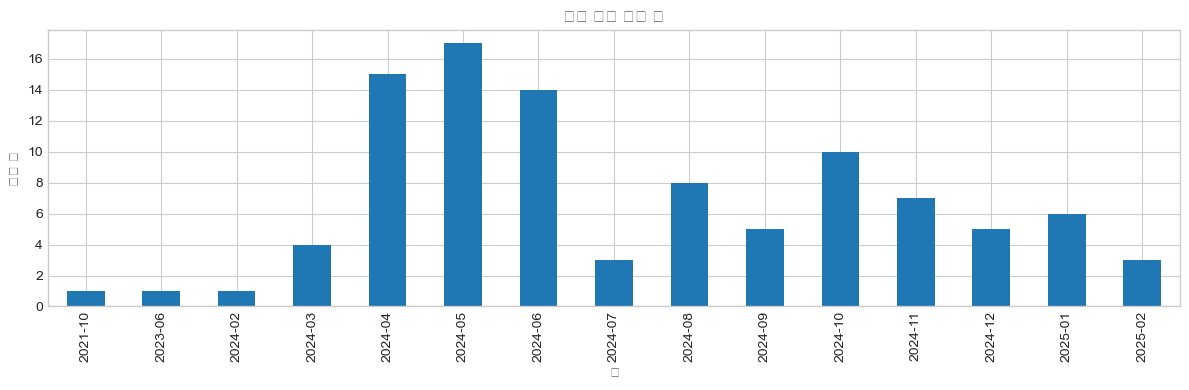

In [32]:
# 날짜 분포
df['공개 일자'] = pd.to_datetime(df['공개 일자'], errors='coerce')
df['공개월'] = df['공개 일자'].dt.to_period('M')

print('=== 공개 일자 범위 ===')
print(f"최초: {df['공개 일자'].min()}")
print(f"최근: {df['공개 일자'].max()}")

df['공개월'].value_counts().sort_index().plot(kind='bar', figsize=(12, 4))
plt.title('월별 공개 문서 수')
plt.xlabel('월')
plt.ylabel('문서 수')
plt.tight_layout()
plt.show()

## 3. 텍스트 분석

=== 텍스트 길이(글자 수) 통계 ===
count      100.0
mean      3844.0
std       3693.0
min         89.0
25%       1198.0
50%       2583.0
75%       5842.0
max      18335.0
Name: 텍스트_길이, dtype: float64

텍스트 비어있는 문서: 0개
텍스트 1000자 미만 문서: 21개


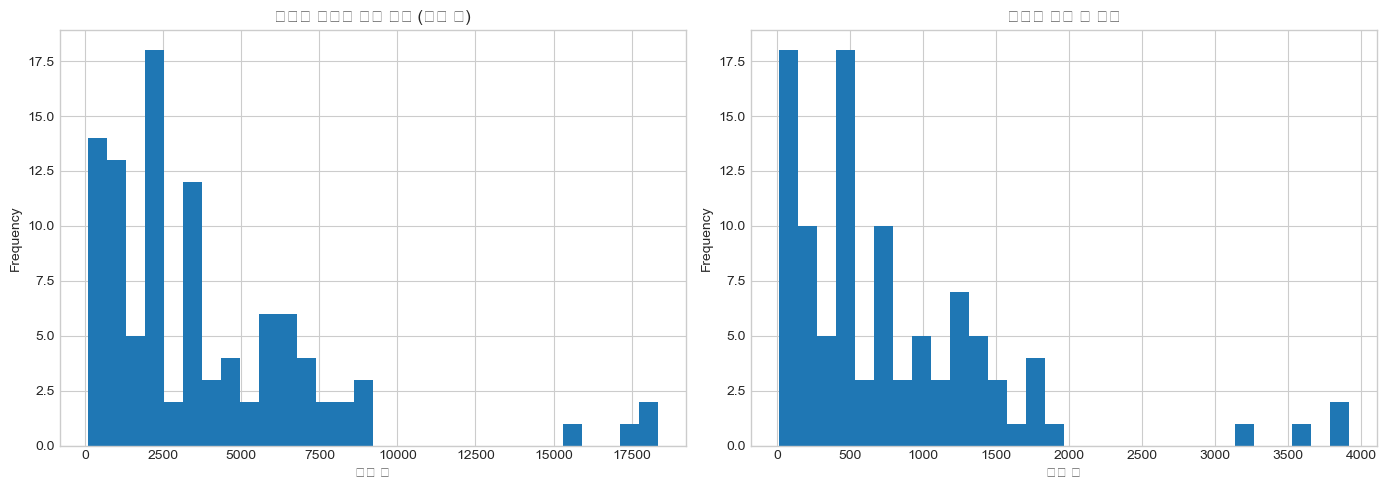

In [33]:
# 텍스트 길이 분석
df['텍스트_길이'] = df['텍스트'].fillna('').str.len()
df['텍스트_단어수'] = df['텍스트'].fillna('').str.split().str.len()

print('=== 텍스트 길이(글자 수) 통계 ===')
print(df['텍스트_길이'].describe().round(0))

print(f'\n텍스트 비어있는 문서: {(df["텍스트_길이"] == 0).sum()}개')
print(f'텍스트 1000자 미만 문서: {(df["텍스트_길이"] < 1000).sum()}개')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

df['텍스트_길이'].plot.hist(bins=30, ax=axes[0])
axes[0].set_title('문서별 텍스트 길이 분포 (글자 수)')
axes[0].set_xlabel('글자 수')

df['텍스트_단어수'].plot.hist(bins=30, ax=axes[1])
axes[1].set_title('문서별 단어 수 분포')
axes[1].set_xlabel('단어 수')

plt.tight_layout()
plt.show()

In [34]:
# 사업 요약 분석
df['요약_길이'] = df['사업 요약'].fillna('').str.len()

print('=== 사업 요약 길이 통계 ===')
print(df['요약_길이'].describe().round(0))
print(f'\n사업 요약 비어있는 문서: {(df["요약_길이"] == 0).sum()}개')

# 요약 예시
print('\n=== 사업 요약 예시 (상위 3개) ===')
for i, row in df.head(3).iterrows():
    print(f"\n[{row['사업명']}]")
    print(f"  {str(row['사업 요약'])[:200]}...")

=== 사업 요약 길이 통계 ===
count    100.0
mean     269.0
std       73.0
min      142.0
25%      220.0
50%      250.0
75%      297.0
max      524.0
Name: 요약_길이, dtype: float64

사업 요약 비어있는 문서: 0개

=== 사업 요약 예시 (상위 3개) ===

[한영대학교 특성화 맞춤형 교육환경 구축 - 트랙운영 학사정보시스템 고도화]
  - 한영대학교 특성화 맞춤형 교육환경 구축을 위해 트랙운영 학사정보시스템을 고도화한다.
- 트랙제도를 도입하여 다양한 진로 선택 기회를 제공하고 산업현장의 경쟁력을 강화한다.
- 효과적인 교육과정 지원 및 대학 체제 개편에 대한 대응체계를 확립한다.
- 트랙기반 교육과정 운영 및 관리 체계를 개선하고 교수자-학습자 중심의 교육환경을 조성한다.
- 학사운영 ...

[2024년 대학산학협력활동 실태조사 시스템(UICC) 기능개선]
  - 사업 개요: 2024년 대학 산학협력활동 실태조사 시스템(UICC) 기능개선
- 추진배경: 대학 산학협력활동 실태조사를 안정적으로 운영하고 사용자 편의성을 개선하기 위해 필요
- 사업범위: UICC 시스템 기능개선 및 운영지원, 대학정보공시 연계 기능 개선
- 기대효과: 실태조사를 안정적으로 운영하고 사용자 편의성을 개선하여 대학 산학협력활동을 효율적으...

[EIP3.0 고압가스 안전관리 시스템 구축 용역]
  - 사업 개요: EIP3.0 고압가스 안전관리 시스템 구축 용역
- 추진배경: 안전사고 증가, 법적 요구사항, 연구 환경 보호에 대한 필요성
- 사업범위: 화학물질 운영현황 통계 정보 제공, 고압가스 화학물질 관리 시스템 구축, 안전성 검토 과정 시스템 고도화, 법적 준수와 연구실 관리 시스템 고도화, 화학제품 폐기-회수 관리 시스템 고도화
- 기대효과: ...


## 4. 원본 파일(files/) 매칭 확인

In [35]:
# 원본 파일 vs CSV 파일명 매칭 (macOS 유니코드 NFD 정규화 필요)
import unicodedata

actual_files_raw = os.listdir('files/')
actual_files = {unicodedata.normalize('NFC', f) for f in actual_files_raw}
csv_files = {unicodedata.normalize('NFC', f) for f in df['파일명'].dropna().unique()}

print(f'files/ 폴더 파일 수: {len(actual_files)}')
print(f'CSV 파일명 고유값 수: {len(csv_files)}')

matched = actual_files & csv_files
only_in_folder = actual_files - csv_files
only_in_csv = csv_files - actual_files

print(f'\n매칭된 파일: {len(matched)}개')
print(f'폴더에만 있는 파일 (CSV에 없음): {len(only_in_folder)}개')
for f in sorted(only_in_folder):
    print(f'  - {f}')

print(f'CSV에만 있는 파일 (폴더에 없음): {len(only_in_csv)}개')
for f in sorted(only_in_csv):
    print(f'  - {f}')

files/ 폴더 파일 수: 101
CSV 파일명 고유값 수: 100

매칭된 파일: 100개
폴더에만 있는 파일 (CSV에 없음): 1개
  - 고려대학교_차세대 포털·학사 정보시스템 구축사업.docx
CSV에만 있는 파일 (폴더에 없음): 0개


=== 파일 크기 통계 (KB) ===
count      101.0
mean      1655.8
std       2666.5
min        143.5
25%        519.5
50%        941.0
75%       1576.0
max      23546.0
Name: 크기(KB), dtype: float64

=== 확장자별 분포 ===
확장자
.hwp     96
.pdf      4
.docx     1
Name: count, dtype: int64


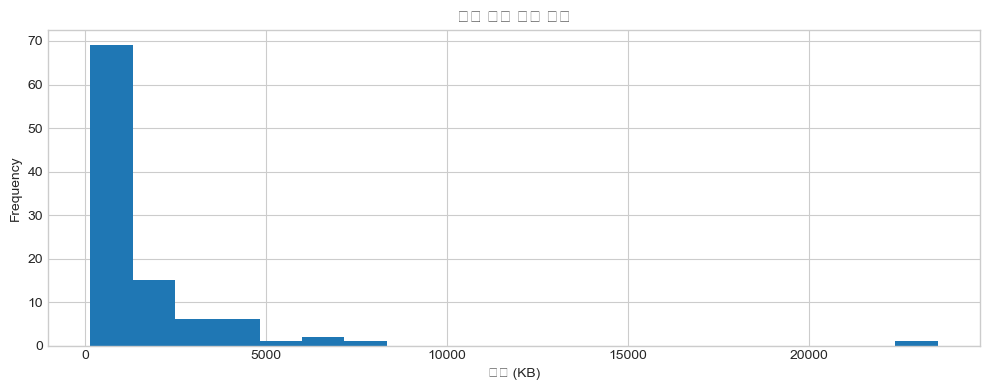

In [36]:
# 파일 크기 분포
file_sizes = []
for f in os.listdir('files/'):
    path = os.path.join('files/', f)
    size_kb = os.path.getsize(path) / 1024
    ext = os.path.splitext(f)[1].lower()
    file_sizes.append({'파일명': f, '크기(KB)': size_kb, '확장자': ext})

df_files = pd.DataFrame(file_sizes)

print('=== 파일 크기 통계 (KB) ===')
print(df_files['크기(KB)'].describe().round(1))

print(f'\n=== 확장자별 분포 ===')
print(df_files['확장자'].value_counts())

df_files['크기(KB)'].plot.hist(bins=20, figsize=(10, 4))
plt.title('원본 파일 크기 분포')
plt.xlabel('크기 (KB)')
plt.tight_layout()
plt.show()

## 5. RAG 관점 인사이트

In [37]:
# 청킹 전략을 위한 텍스트 길이 상세 분석
print('=== 텍스트 길이 구간별 문서 수 ===')
length_bins = [0, 1000, 5000, 10000, 30000, 50000, float('inf')]
length_labels = ['~1K', '1K~5K', '5K~10K', '10K~30K', '30K~50K', '50K~']
df['길이구간'] = pd.cut(df['텍스트_길이'], bins=length_bins, labels=length_labels)
print(df['길이구간'].value_counts().sort_index())

# 가장 짧은/긴 문서
print('\n=== 가장 짧은 문서 5개 ===')
short = df.nsmallest(5, '텍스트_길이')[['사업명', '텍스트_길이', '파일형식']]
print(short.to_string(index=False))

print('\n=== 가장 긴 문서 5개 ===')
long = df.nlargest(5, '텍스트_길이')[['사업명', '텍스트_길이', '파일형식']]
print(long.to_string(index=False))

=== 텍스트 길이 구간별 문서 수 ===
길이구간
~1K        21
1K~5K      50
5K~10K     25
10K~30K     4
30K~50K     0
50K~        0
Name: count, dtype: int64

=== 가장 짧은 문서 5개 ===
                                       사업명  텍스트_길이 파일형식
   2024년 건설기술에 관한 특허·실용신안 활용실적 관리시스템 개편 용역      89  hwp
              JST 공유대학(원) xAPI기반 LRS시스템 구축     130  hwp
2025 구미아시아육상경기선수권대회 종합정보시스템 및 홈페이지 등 구축 용역     186  hwp
     [사전공개] 학업성취도 다차원 종단분석 통합시스템 1차 고도화 용역     220  pdf
                EIP3.0 고압가스 안전관리 시스템 구축 용역     234  hwp

=== 가장 긴 문서 5개 ===
                             사업명  텍스트_길이 파일형식
      모바일오피스 시스템 고도화 용역(총체 및 1차)   18335  hwp
우즈벡-키르기즈스탄 기후변화대응 스마트 관개시스템 구축사업   18039  hwp
             2세대 전자조달시스템  기반구축사업   17414  hwp
   2024년 버스정보시스템 확대 구축 및 기능개선 용역   15856  hwp
  의료기기산업 종합정보시스템(정보관리기관) 기능개선 사업    9007  hwp


In [38]:
# 메타데이터 활용 가능성 점검
print('=== 메타데이터 필터링에 활용 가능한 컬럼 ===\n')

cols = ['공고 번호', '사업명', '사업 금액', '발주 기관', '공개 일자', '파일형식']
for col in cols:
    non_null = df[col].notna().sum()
    unique = df[col].nunique()
    print(f'{col:12s} | 비결측: {non_null:4d}/{len(df)} | 고유값: {unique}')

# 텍스트 내 특수문자/깨진 텍스트 샘플 확인
print('\n=== 텍스트 샘플 (첫 번째 문서 앞 500자) ===')
sample_text = str(df.iloc[0]['텍스트'])[:500]
print(sample_text)

=== 메타데이터 필터링에 활용 가능한 컬럼 ===

공고 번호        | 비결측:   82/100 | 고유값: 82
사업명          | 비결측:  100/100 | 고유값: 99
사업 금액        | 비결측:   99/100 | 고유값: 82
발주 기관        | 비결측:  100/100 | 고유값: 87
공개 일자        | 비결측:  100/100 | 고유값: 99
파일형식         | 비결측:  100/100 | 고유값: 2

=== 텍스트 샘플 (첫 번째 문서 앞 500자) ===
    
 
2024년 특성화 맞춤형 교육환경 구축 – 트랙운영 학사정보시스템 고도화
  제안요청서

2024. 10.
   
 
   
목   차
Ⅰ. 사업 안내          -            1
 1. 사업개요          -            1
 2. 추진배경 및 필요성           -            1
 3. 기대효과           -            1
  Ⅱ. 구축 방안          -            2
 1. 구축목표          -            2
 2. 구축일정           -            2
 3. 구축범위           -            3
  Ⅲ. 제안 요청 내용          -            4
 1. 제안 요청 개요          -            4
  Ⅳ. 제안안내 사항          -            5
 1. 입찰 및 계약방법          -     


## 6. 원본 파일 직접 파싱 (HWP/PDF)
CSV의 `텍스트` 컬럼은 원본 문서의 일부만 담고 있을 수 있음.  
원본 HWP/PDF를 직접 파싱하여 **실제 텍스트 양, 이미지 수, 테이블 구조**를 분석합니다.

In [39]:
import olefile, zlib, struct

def extract_hwp_text(filepath):
    """HWP 파일에서 본문 텍스트와 이미지 정보를 추출"""
    if not olefile.isOleFile(filepath):
        return '', 0, 0
    
    ole = olefile.OleFileIO(filepath)
    header = ole.openstream('FileHeader').read()
    is_compressed = header[36] & 1
    
    all_text = []
    img_count = 0
    section_count = 0
    
    for stream in ole.listdir():
        path = '/'.join(stream)
        
        if path.startswith('BodyText/'):
            section_count += 1
            data = ole.openstream(path).read()
            if is_compressed:
                try:
                    data = zlib.decompress(data, -15)
                except:
                    pass
            
            text_parts = []
            i = 0
            while i < len(data) - 4:
                if i + 4 > len(data):
                    break
                header_val = struct.unpack('<I', data[i:i+4])[0]
                tag_id = header_val & 0x3FF
                size = (header_val >> 20) & 0xFFF
                
                if size == 0xFFF:
                    if i + 8 <= len(data):
                        size = struct.unpack('<I', data[i+4:i+8])[0]
                        i += 8
                    else:
                        break
                else:
                    i += 4
                
                if tag_id == 67:  # PARA_TEXT
                    raw = data[i:i+size]
                    j = 0
                    while j < len(raw) - 1:
                        code = struct.unpack('<H', raw[j:j+2])[0]
                        if code == 0:
                            break
                        elif code < 32:
                            if code in (1,2,3,11,12,13,14,15,16,17,18,21,22,23,24):
                                j += 16
                            elif code == 9:
                                text_parts.append('\t')
                                j += 16
                            elif code == 10:
                                text_parts.append('\n')
                                j += 2
                            else:
                                j += 2
                        else:
                            text_parts.append(chr(code))
                            j += 2
                
                i += size
            
            all_text.append(''.join(text_parts))
        
        elif path.startswith('BinData/'):
            img_count += 1
    
    ole.close()
    return '\n'.join(all_text), img_count, section_count

print('HWP 파싱 함수 준비 완료')

HWP 파싱 함수 준비 완료


In [40]:
import pdfplumber
import docx as python_docx

def extract_pdf_info(filepath):
    """PDF 파일에서 텍스트, 테이블, 이미지 정보를 추출"""
    try:
        with pdfplumber.open(filepath) as pdf:
            pages = len(pdf.pages)
            texts = []
            table_count = 0
            image_count = 0
            all_tables = []
            for page in pdf.pages:
                t = page.extract_text() or ''
                texts.append(t)
                tables = page.extract_tables()
                table_count += len(tables)
                all_tables.extend(tables)
                image_count += len(page.images)
            return '\n'.join(texts), pages, table_count, image_count, all_tables
    except Exception as e:
        return '', 0, 0, 0, []

def extract_docx_info(filepath):
    """DOCX 파일에서 텍스트, 표, 이미지 정보를 추출"""
    try:
        doc = python_docx.Document(filepath)
        # 본문 텍스트
        text_parts = [para.text for para in doc.paragraphs]
        # 표 추출 (텍스트로 변환)
        table_texts = []
        for table in doc.tables:
            rows = []
            for row in table.rows:
                cells = [cell.text.strip() for cell in row.cells]
                rows.append(' | '.join(cells))
            table_texts.append('\n'.join(rows))
        # 이미지 수
        img_count = sum(1 for rel in doc.part.rels.values() if "image" in rel.reltype)
        # 표 텍스트를 본문에 합침
        full_text = '\n'.join(text_parts)
        if table_texts:
            full_text += '\n\n[표 데이터]\n' + '\n\n'.join(table_texts)
        return full_text, len(doc.tables), img_count
    except Exception as e:
        return '', 0, 0

print('PDF / DOCX 파싱 함수 준비 완료')

PDF / DOCX 파싱 함수 준비 완료


In [41]:
# 전체 파일 파싱 - HWP, PDF, DOCX 모두 처리
from collections import defaultdict

file_list = os.listdir('files/')
parse_results = []

for i, fname in enumerate(sorted(file_list)):
    nfc_name = unicodedata.normalize('NFC', fname)
    filepath = os.path.join('files/', fname)
    ext = os.path.splitext(fname)[1].lower()
    file_size_kb = os.path.getsize(filepath) / 1024
    
    if ext == '.hwp':
        raw_text, img_count, section_count = extract_hwp_text(filepath)
        parse_results.append({
            '파일명_nfc': nfc_name, '확장자': ext,
            '파일크기_KB': round(file_size_kb, 1),
            '원본_텍스트_길이': len(raw_text),
            '원본_단어수': len(raw_text.split()),
            '이미지수': img_count,
            '섹션수': section_count,
            '원본_텍스트': raw_text
        })
    elif ext == '.pdf':
        raw_text, pages, table_count, img_count, _ = extract_pdf_info(filepath)
        parse_results.append({
            '파일명_nfc': nfc_name, '확장자': ext,
            '파일크기_KB': round(file_size_kb, 1),
            '원본_텍스트_길이': len(raw_text),
            '원본_단어수': len(raw_text.split()),
            '이미지수': img_count,
            '페이지수': pages,
            '테이블수': table_count,
            '원본_텍스트': raw_text
        })
    elif ext == '.docx':
        raw_text, table_count, img_count = extract_docx_info(filepath)
        parse_results.append({
            '파일명_nfc': nfc_name, '확장자': ext,
            '파일크기_KB': round(file_size_kb, 1),
            '원본_텍스트_길이': len(raw_text),
            '원본_단어수': len(raw_text.split()),
            '이미지수': img_count,
            '테이블수': table_count,
            '원본_텍스트': raw_text
        })
    else:
        parse_results.append({
            '파일명_nfc': nfc_name, '확장자': ext,
            '파일크기_KB': round(file_size_kb, 1),
            '원본_텍스트_길이': 0, '원본_단어수': 0,
            '이미지수': 0, '원본_텍스트': ''
        })
    
    if (i + 1) % 20 == 0:
        print(f'  {i+1}/{len(file_list)} 파일 처리 완료...')

df_parsed = pd.DataFrame(parse_results)
print(f'\n전체 {len(df_parsed)}개 파일 파싱 완료!')
print(f'\n=== 확장자별 텍스트 길이 통계 ===')
print(df_parsed.groupby('확장자')['원본_텍스트_길이'].describe().round(0))

# 각 포맷별 상세
for ext_name, ext_group in df_parsed.groupby('확장자'):
    print(f'\n--- {ext_name} ({len(ext_group)}개) ---')
    for _, row in ext_group.iterrows():
        extras = []
        if pd.notna(row.get('페이지수')): extras.append(f"{int(row['페이지수'])}페이지")
        if pd.notna(row.get('테이블수')): extras.append(f"표{int(row['테이블수'])}개")
        extras.append(f"이미지{row['이미지수']}개")
        print(f"  {row['파일명_nfc'][:50]} | {row['원본_텍스트_길이']:,}자 | {' | '.join(extras)}")

  20/101 파일 처리 완료...
  40/101 파일 처리 완료...
  60/101 파일 처리 완료...
  80/101 파일 처리 완료...
  100/101 파일 처리 완료...

전체 101개 파일 파싱 완료!

=== 확장자별 텍스트 길이 통계 ===
       count      mean      std      min      25%       50%       75%  \
확장자                                                                     
.docx    1.0   54174.0      NaN  54174.0  54174.0   54174.0   54174.0   
.hwp    96.0   67674.0  20542.0  41731.0  53262.0   62926.0   74542.0   
.pdf     4.0  114562.0  58841.0  45078.0  93342.0  112113.0  133333.0   

            max  
확장자              
.docx   54174.0  
.hwp   142582.0  
.pdf   188943.0  

--- .docx (1개) ---
  고려대학교_차세대 포털·학사 정보시스템 구축사업.docx | 54,174자 | 표105개 | 이미지5개

--- .hwp (96개) ---
  (사)벤처기업협회_2024년 벤처확인종합관리시스템 기능 고도화 용역사업 .hwp | 100,639자 | 이미지9개
  (사)부산국제영화제_2024년 BIFF & ACFM 온라인서비스 재개발 및 행사지원시.hw | 50,516자 | 이미지17개
  (사）한국대학스포츠협의회_KUSF 체육특기자 경기기록 관리시스템 개발.hwp | 71,511자 | 이미지6개
  (재)예술경영지원센터_통합 정보시스템 구축 사전 컨설팅.hwp | 41,739자 | 이미지6개
  2025 구미 아시아육상경기선수권대회 조직위원회_2025 구미아시아

## 7. CSV 텍스트 vs 원본 파싱 텍스트 비교
CSV에 저장된 텍스트가 원본의 전체를 담고 있는지 확인합니다.

=== CSV vs 원본 텍스트 길이 비교 ===
CSV 평균 텍스트 길이: 3844자
원본 평균 텍스트 길이: 69549자
평균 텍스트 손실률: 94.0%


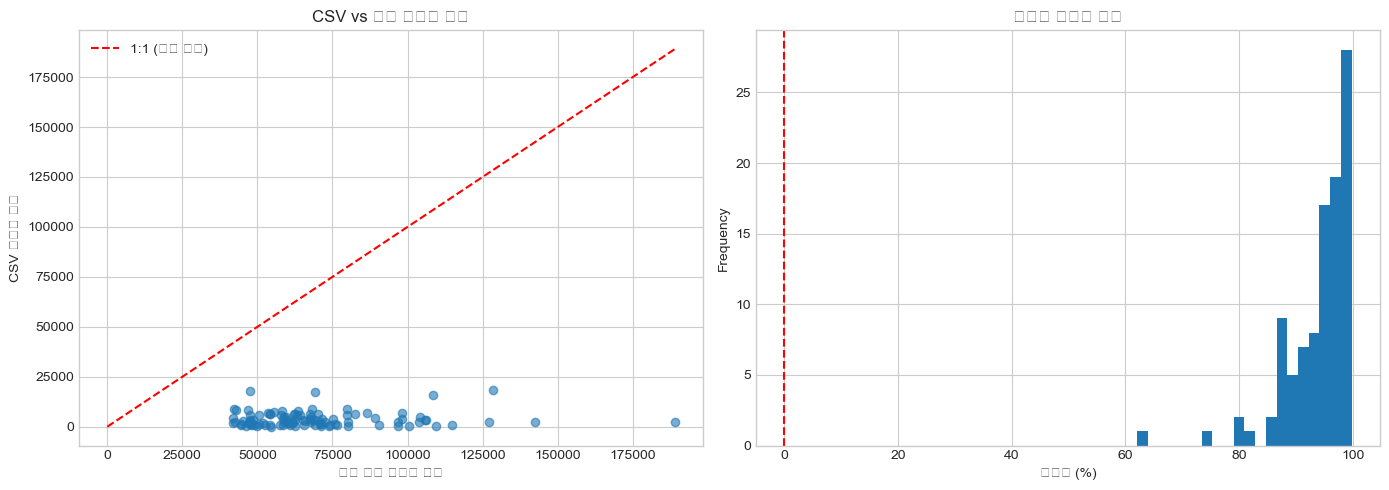


=== 텍스트 손실이 큰 문서 Top 5 ===
                                    사업명  텍스트_길이  원본_텍스트_길이  텍스트_손실률
             EIP3.0 고압가스 안전관리 시스템 구축 용역     234      96942     99.8
  [사전공개] 학업성취도 다차원 종단분석 통합시스템 1차 고도화 용역     220     109430     99.8
2024년 건설기술에 관한 특허·실용신안 활용실적 관리시스템 개편 용역      89      54581     99.8
           JST 공유대학(원) xAPI기반 LRS시스템 구축     130      71300     99.8
              스포츠윤리센터 LMS(학습지원시스템) 기능개선     298      73988     99.6


In [42]:
# CSV 텍스트 길이 vs 원본 파싱 텍스트 길이 비교
df['파일명_nfc'] = df['파일명'].apply(lambda x: unicodedata.normalize('NFC', str(x)))
df_compare = df.merge(
    df_parsed[['파일명_nfc', '원본_텍스트_길이', '원본_단어수', '이미지수']],
    on='파일명_nfc', how='left'
)

df_compare['텍스트_손실률'] = (
    (1 - df_compare['텍스트_길이'] / df_compare['원본_텍스트_길이'].replace(0, np.nan)) * 100
).round(1)

print('=== CSV vs 원본 텍스트 길이 비교 ===')
print(f"CSV 평균 텍스트 길이: {df_compare['텍스트_길이'].mean():.0f}자")
print(f"원본 평균 텍스트 길이: {df_compare['원본_텍스트_길이'].mean():.0f}자")
print(f"평균 텍스트 손실률: {df_compare['텍스트_손실률'].mean():.1f}%")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 산점도
axes[0].scatter(df_compare['원본_텍스트_길이'], df_compare['텍스트_길이'], alpha=0.6)
max_val = max(df_compare['원본_텍스트_길이'].max(), df_compare['텍스트_길이'].max())
axes[0].plot([0, max_val], [0, max_val], 'r--', label='1:1 (손실 없음)')
axes[0].set_xlabel('원본 파싱 텍스트 길이')
axes[0].set_ylabel('CSV 텍스트 길이')
axes[0].set_title('CSV vs 원본 텍스트 길이')
axes[0].legend()

# 손실률 분포
df_compare['텍스트_손실률'].dropna().plot.hist(bins=20, ax=axes[1])
axes[1].set_title('텍스트 손실률 분포')
axes[1].set_xlabel('손실률 (%)')
axes[1].axvline(x=0, color='r', linestyle='--')

plt.tight_layout()
plt.show()

# 손실이 큰 문서
print('\n=== 텍스트 손실이 큰 문서 Top 5 ===')
top_loss = df_compare.nlargest(5, '텍스트_손실률')[['사업명', '텍스트_길이', '원본_텍스트_길이', '텍스트_손실률']]
print(top_loss.to_string(index=False))

## 8. 텍스트 품질 분석
특수문자, 깨진 텍스트, 공백 패턴 등을 점검합니다.

=== 텍스트 구성 비율 통계 ===
한글비율       | 평균:  64.1% | 최소:  53.3% | 최대:  67.8%
영문비율       | 평균:   3.1% | 최소:   1.0% | 최대:  11.6%
숫자비율       | 평균:   2.4% | 최소:   1.4% | 최대:   3.5%
공백비율       | 평균:  24.2% | 최소:  21.5% | 최대:  27.8%
특수문자비율     | 평균:   6.2% | 최소:   4.3% | 최대:  13.1%

연속공백 3개 이상 발생 문서: 97개
연속줄바꿈 3개 이상 발생 문서: 2개


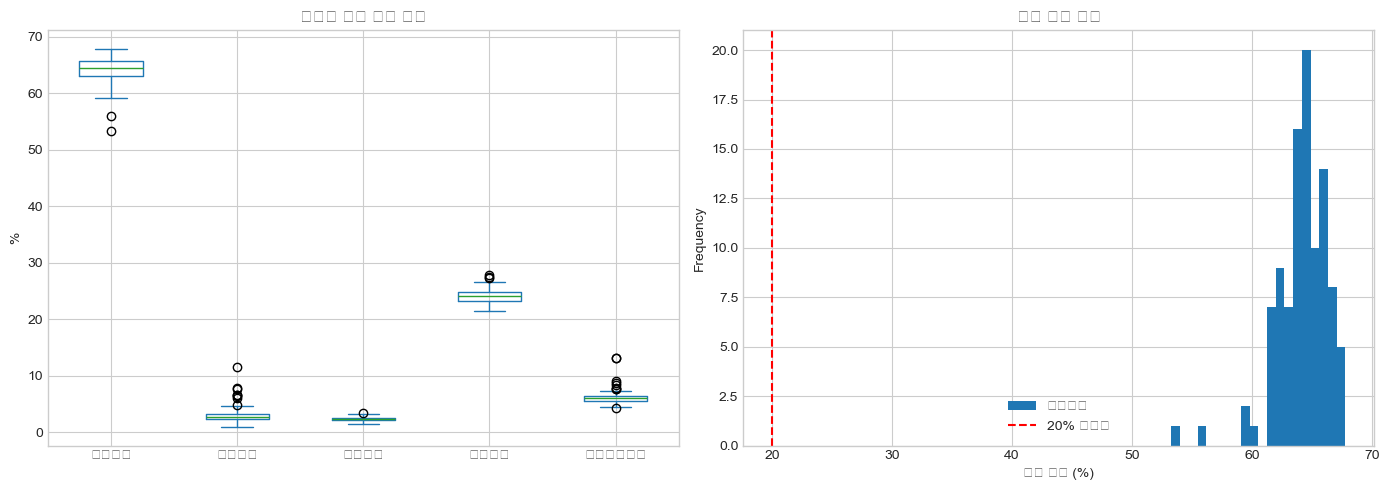


모든 문서의 한글 비율 20% 이상 (양호)


In [43]:
# 텍스트 품질 지표 (원본 파싱 텍스트 기준)
quality_stats = []

for _, row in df_parsed.iterrows():
    text = row['원본_텍스트']
    if not text:
        continue
    
    total_chars = len(text)
    # 한글 비율
    korean = len(re.findall(r'[가-힣]', text))
    # 영문 비율
    english = len(re.findall(r'[a-zA-Z]', text))
    # 숫자 비율
    digits = len(re.findall(r'\d', text))
    # 공백/줄바꿈 비율
    whitespace = len(re.findall(r'\s', text))
    # 특수문자 비율
    special = total_chars - korean - english - digits - whitespace
    # 연속 공백 (깨진 텍스트 징후)
    multi_spaces = len(re.findall(r' {3,}', text))
    # 연속 줄바꿈
    multi_newlines = len(re.findall(r'\n{3,}', text))
    
    quality_stats.append({
        '파일명_nfc': row['파일명_nfc'],
        '한글비율': round(korean / total_chars * 100, 1),
        '영문비율': round(english / total_chars * 100, 1),
        '숫자비율': round(digits / total_chars * 100, 1),
        '공백비율': round(whitespace / total_chars * 100, 1),
        '특수문자비율': round(special / total_chars * 100, 1),
        '연속공백수': multi_spaces,
        '연속줄바꿈수': multi_newlines,
    })

df_quality = pd.DataFrame(quality_stats)

print('=== 텍스트 구성 비율 통계 ===')
for col in ['한글비율', '영문비율', '숫자비율', '공백비율', '특수문자비율']:
    print(f'{col:10s} | 평균: {df_quality[col].mean():5.1f}% | 최소: {df_quality[col].min():5.1f}% | 최대: {df_quality[col].max():5.1f}%')

print(f'\n연속공백 3개 이상 발생 문서: {(df_quality["연속공백수"] > 0).sum()}개')
print(f'연속줄바꿈 3개 이상 발생 문서: {(df_quality["연속줄바꿈수"] > 0).sum()}개')

# 시각화
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
df_quality[['한글비율', '영문비율', '숫자비율', '공백비율', '특수문자비율']].plot.box(ax=axes[0])
axes[0].set_title('텍스트 구성 비율 분포')
axes[0].set_ylabel('%')

# 한글 비율이 낮은 문서 (품질 의심)
df_quality['한글비율'].plot.hist(bins=20, ax=axes[1])
axes[1].set_title('한글 비율 분포')
axes[1].set_xlabel('한글 비율 (%)')
axes[1].axvline(x=20, color='r', linestyle='--', label='20% 기준선')
axes[1].legend()

plt.tight_layout()
plt.show()

# 한글 비율이 낮은 문서 (텍스트 추출 실패 가능성)
low_korean = df_quality[df_quality['한글비율'] < 20]
if len(low_korean) > 0:
    print(f'\n⚠ 한글 비율 20% 미만 문서 {len(low_korean)}개 (텍스트 추출 품질 확인 필요):')
    for _, row in low_korean.iterrows():
        print(f"  {row['파일명_nfc'][:50]} (한글 {row['한글비율']}%)")
else:
    print('\n모든 문서의 한글 비율 20% 이상 (양호)')

## 9. 토큰 수 추정 (청킹 전략용)
OpenAI 토크나이저(`tiktoken`)로 문서별 토큰 수를 추정합니다.  
청크 크기와 임베딩 모델의 max token 제한을 고려한 전략 수립에 활용합니다.

=== 문서별 토큰 수 통계 (원본 파싱 기준) ===
count       101.0
mean      41435.0
std       14841.0
min       24790.0
25%       31345.0
50%       37650.0
75%       45614.0
max      115815.0
Name: 토큰수, dtype: float64

총 토큰 수: 4,184,924


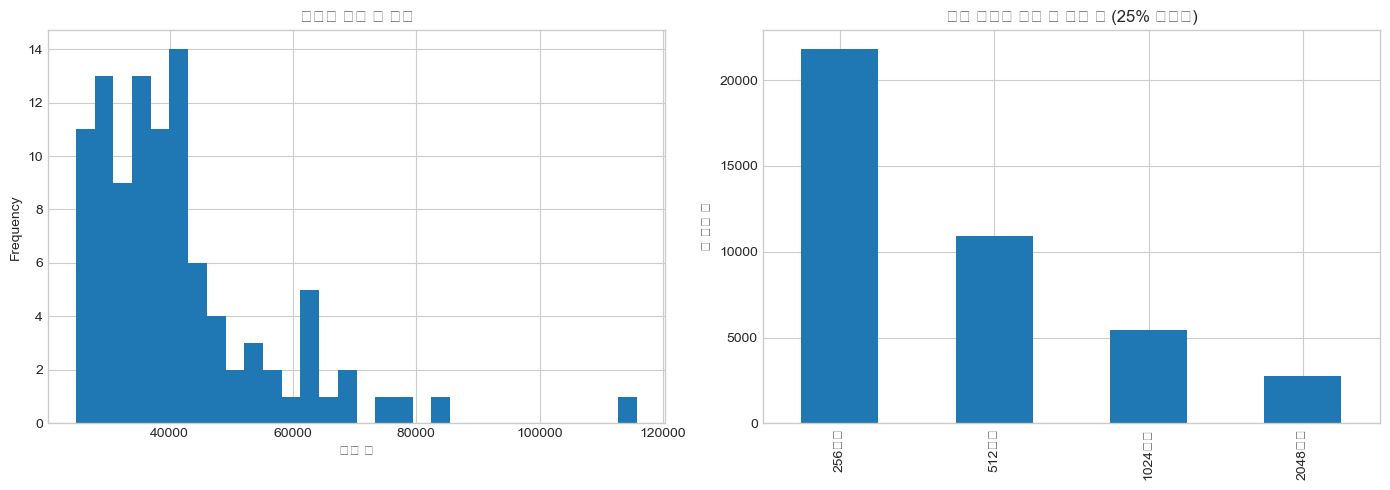


=== 청크 크기별 예상 총 청크 수 ===
  256토큰: 21,814개
  512토큰: 10,913개
  1024토큰: 5,468개
  2048토큰: 2,744개

⚠ text-embedding-3-small 토큰 제한(8191) 초과 문서: 101개
  → 반드시 청킹이 필요합니다.


In [44]:
import tiktoken

enc = tiktoken.encoding_for_model('gpt-4o-mini')

# 원본 파싱 텍스트 기준 토큰 수 계산
df_parsed['토큰수'] = df_parsed['원본_텍스트'].apply(lambda x: len(enc.encode(x)) if x else 0)

print('=== 문서별 토큰 수 통계 (원본 파싱 기준) ===')
print(df_parsed['토큰수'].describe().round(0))
print(f'\n총 토큰 수: {df_parsed["토큰수"].sum():,}')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

df_parsed['토큰수'].plot.hist(bins=30, ax=axes[0])
axes[0].set_title('문서별 토큰 수 분포')
axes[0].set_xlabel('토큰 수')

# 청크 크기별 예상 청크 수
chunk_sizes = [256, 512, 1024, 2048]
chunk_data = {}
for cs in chunk_sizes:
    overlap = cs // 4  # 25% 오버랩 가정
    chunk_data[f'{cs}토큰'] = df_parsed['토큰수'].apply(
        lambda t: max(1, int(np.ceil((t - overlap) / (cs - overlap)))) if t > 0 else 0
    ).sum()

pd.Series(chunk_data).plot.bar(ax=axes[1])
axes[1].set_title('청크 크기별 예상 총 청크 수 (25% 오버랩)')
axes[1].set_ylabel('총 청크 수')

plt.tight_layout()
plt.show()

print('\n=== 청크 크기별 예상 총 청크 수 ===')
for k, v in chunk_data.items():
    print(f'  {k}: {v:,}개')

# text-embedding-3-small max token = 8191
over_limit = (df_parsed['토큰수'] > 8191).sum()
print(f'\n⚠ text-embedding-3-small 토큰 제한(8191) 초과 문서: {over_limit}개')
print('  → 반드시 청킹이 필요합니다.' if over_limit > 0 else '  → 전체 문서가 제한 이내입니다.')

## 10. 문서 구조 패턴 분석
RFP 문서의 공통 구조(목차, 섹션 헤더, 표 패턴)를 파악하여 의미 단위 청킹에 활용합니다.

=== RFP 문서 공통 섹션 출현 빈도 ===

사업개요/사업 개요          :  95/101 (94%)
추진배경/필요성            :  81/101 (80%)
구축범위/사업범위           :  82/101 (81%)
요구사항                : 100/101 (99%)
기대효과                :  70/101 (69%)
제안서 작성              :  96/101 (95%)
입찰/참가자격             : 101/101 (100%)
평가기준                :  97/101 (96%)
보안                  : 100/101 (99%)
일정/기간               : 101/101 (100%)


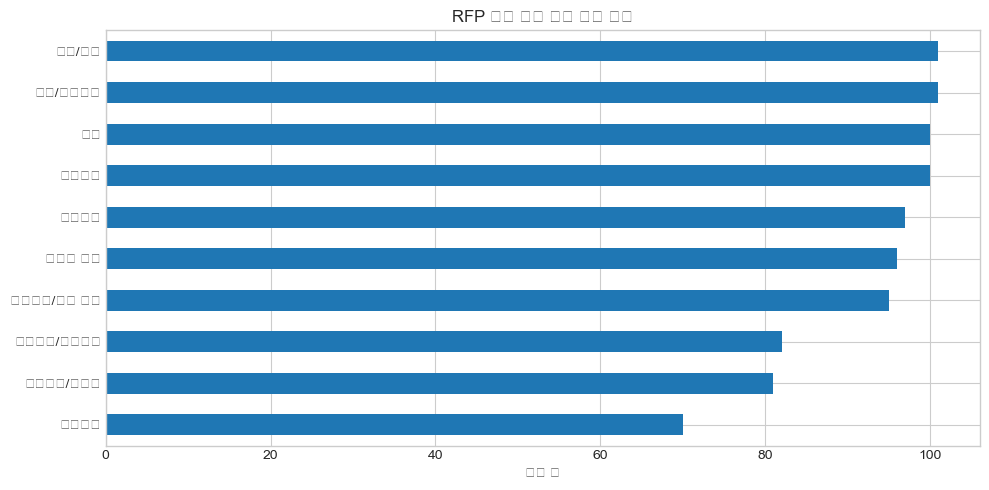

In [45]:
# 문서 구조 패턴 분석
section_patterns = {
    '사업개요/사업 개요': r'사업\s*개요',
    '추진배경/필요성': r'추진\s*배경|필요성',
    '구축범위/사업범위': r'(구축|사업)\s*범위',
    '요구사항': r'요구\s*사항',
    '기대효과': r'기대\s*효과',
    '제안서 작성': r'제안서\s*작성',
    '입찰/참가자격': r'입찰|참가\s*자격',
    '평가기준': r'평가\s*기준',
    '보안': r'보안',
    '일정/기간': r'사업\s*기간|추진\s*일정|구축\s*일정',
}

print('=== RFP 문서 공통 섹션 출현 빈도 ===\n')
section_counts = {}
for pattern_name, pattern in section_patterns.items():
    count = 0
    for text in df_parsed['원본_텍스트']:
        if text and re.search(pattern, text):
            count += 1
    section_counts[pattern_name] = count
    print(f'{pattern_name:20s}: {count:3d}/101 ({count/101*100:.0f}%)')

# 시각화
fig, ax = plt.subplots(figsize=(10, 5))
pd.Series(section_counts).sort_values().plot.barh(ax=ax)
ax.set_title('RFP 문서 공통 섹션 출현 빈도')
ax.set_xlabel('문서 수')
plt.tight_layout()
plt.show()

## 11. 이미지/첨부파일 분석
HWP 문서에 포함된 이미지(BinData) 수와 파일 크기 관계를 분석합니다.

=== 문서별 이미지(BinData) 수 통계 ===
count    101.0
mean      10.0
std       34.8
min        0.0
25%        3.0
50%        5.0
75%        7.0
max      343.0
Name: 이미지수, dtype: float64

이미지 없는 문서: 1개
이미지 있는 문서: 100개
이미지 10개 이상 문서: 13개


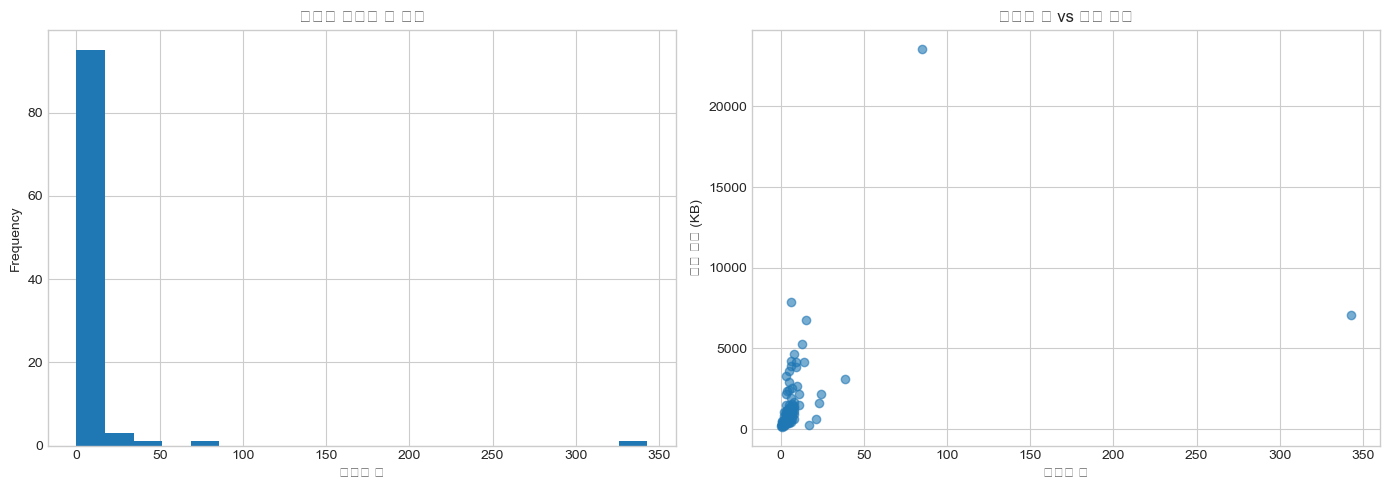


=== 이미지 많은 문서 Top 5 (텍스트 미반영 정보 주의) ===
  고려대학교_차세대 포털·학사 정보시스템 구축사업.pdf | 이미지: 343개 | 텍스트: 188943자 | 크기: 7089.9KB
  KOICA 전자조달_[긴급] [지문] [국제] 우즈베키스탄 열린 의정활동 상하원 .hwp | 이미지: 85개 | 텍스트: 127105자 | 크기: 23546.0KB
  서울특별시_2024년 지도정보 플랫폼 및 전문활용 연계 시스템 고도화 용.pdf | 이미지: 39개 | 텍스트: 114796자 | 크기: 3119.9KB
  서울시립대학교_[사전공개] 학업성취도 다차원 종단분석 통합시스템 1차.pdf | 이미지: 24개 | 텍스트: 109430자 | 크기: 2199.5KB
  한국철도공사 (용역)_예약발매시스템 개량 ISMP 용역.hwp | 이미지: 23개 | 텍스트: 70732자 | 크기: 1600.0KB


In [46]:
# 이미지 포함 현황
print('=== 문서별 이미지(BinData) 수 통계 ===')
print(df_parsed['이미지수'].describe().round(1))
print(f'\n이미지 없는 문서: {(df_parsed["이미지수"] == 0).sum()}개')
print(f'이미지 있는 문서: {(df_parsed["이미지수"] > 0).sum()}개')
print(f'이미지 10개 이상 문서: {(df_parsed["이미지수"] >= 10).sum()}개')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

df_parsed['이미지수'].plot.hist(bins=20, ax=axes[0])
axes[0].set_title('문서별 이미지 수 분포')
axes[0].set_xlabel('이미지 수')

# 파일크기 vs 이미지수 관계
axes[1].scatter(df_parsed['이미지수'], df_parsed['파일크기_KB'], alpha=0.6)
axes[1].set_xlabel('이미지 수')
axes[1].set_ylabel('파일 크기 (KB)')
axes[1].set_title('이미지 수 vs 파일 크기')

plt.tight_layout()
plt.show()

# 이미지가 많은 문서 (텍스트로 추출 못하는 정보가 많을 수 있음)
print('\n=== 이미지 많은 문서 Top 5 (텍스트 미반영 정보 주의) ===')
top_img = df_parsed.nlargest(5, '이미지수')[['파일명_nfc', '이미지수', '원본_텍스트_길이', '파일크기_KB']]
for _, row in top_img.iterrows():
    print(f"  {row['파일명_nfc'][:50]} | 이미지: {row['이미지수']}개 | 텍스트: {row['원본_텍스트_길이']}자 | 크기: {row['파일크기_KB']}KB")

### 11-1. HWP 내부 이미지 추출 및 미리보기
HWP 파일의 BinData에 포함된 이미지를 추출하여 어떤 정보가 담겨있는지 확인합니다.  
(표, 도표, 로고 등 → 텍스트로 추출되지 않는 정보 파악)


=== KOICA 전자조달_[긴급] [지문] [국제] 우즈베키스탄 열린 의정활동 상하원 .hwp (이미지 85개 중 4개 미리보기) ===


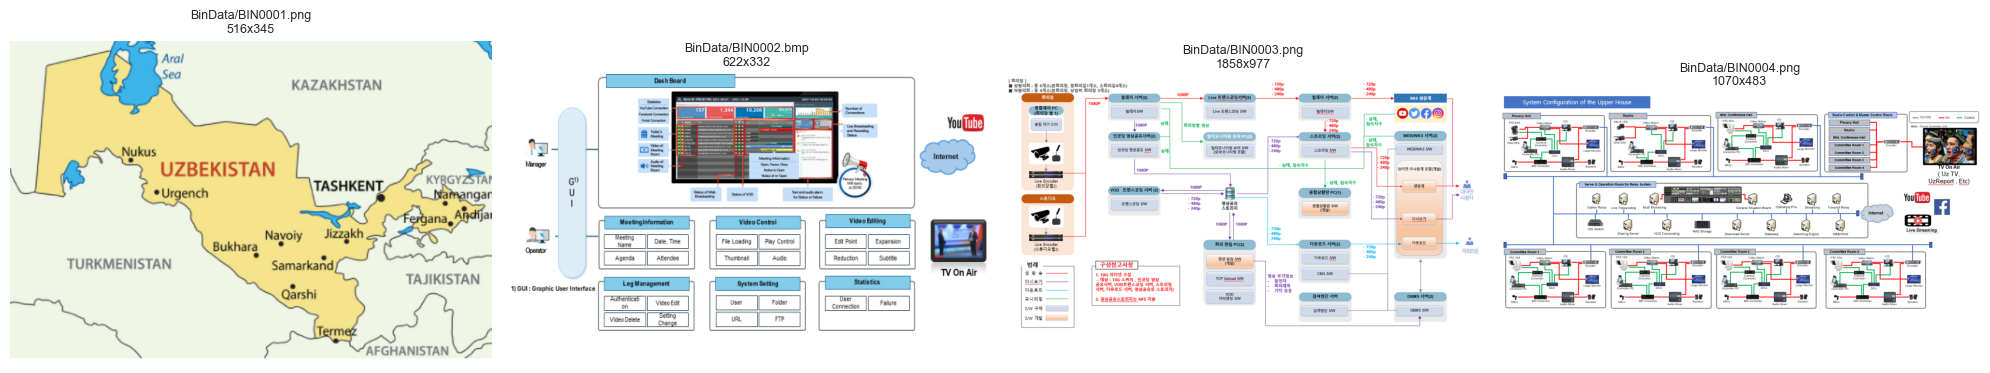


=== 한국철도공사 (용역)_예약발매시스템 개량 ISMP 용역.hwp (이미지 23개 중 4개 미리보기) ===


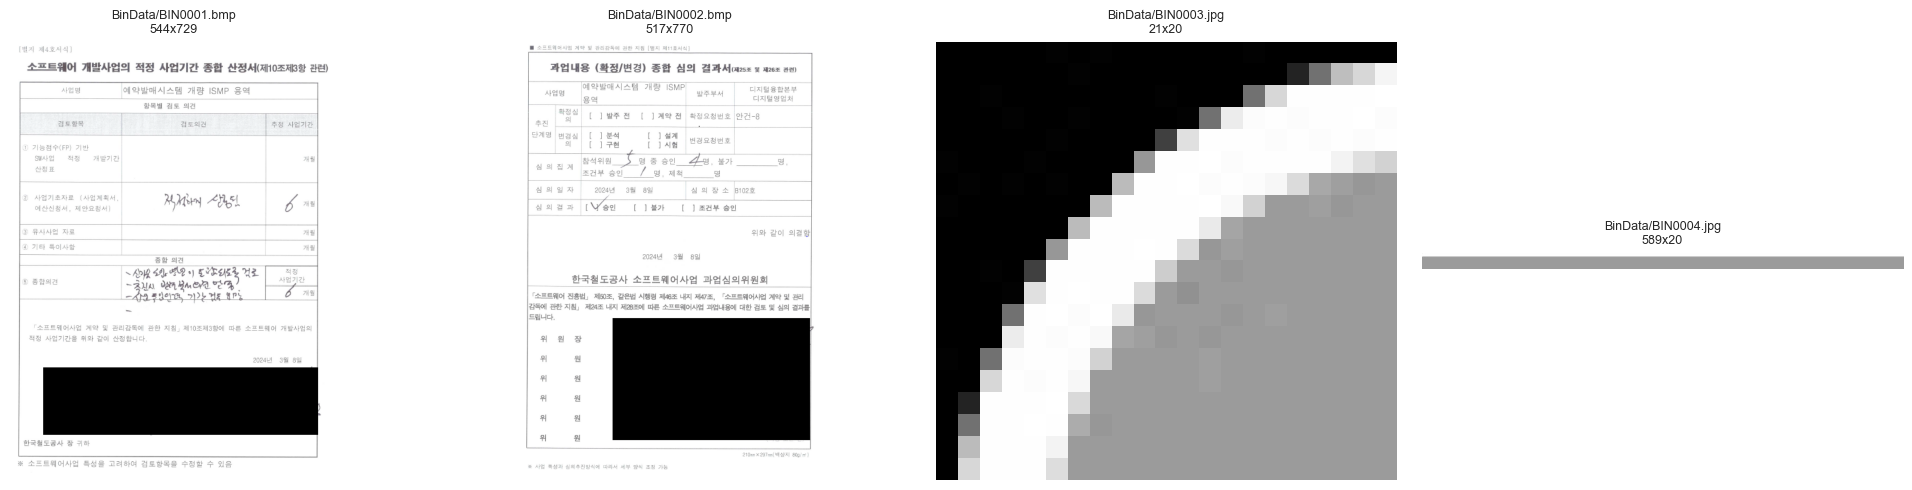


=== (사)부산국제영화제_2024년 BIFF & ACFM 온라인서비스 재개발 및 행사지원시.hw (이미지 17개 중 4개 미리보기) ===


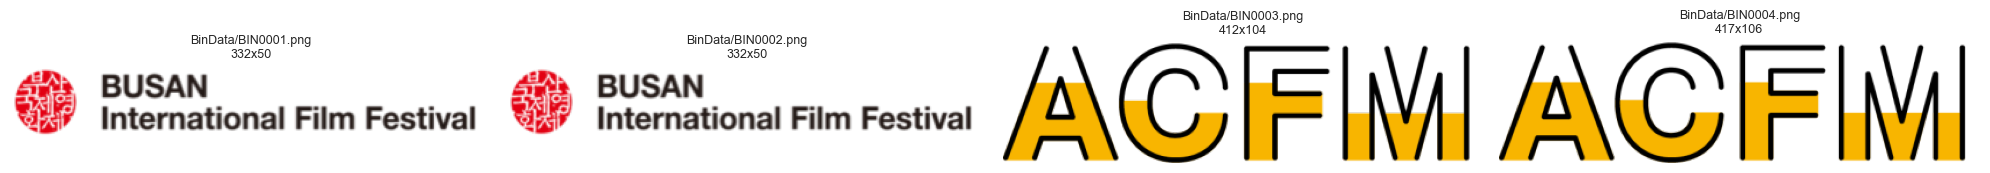

In [47]:
from PIL import Image
import io

def extract_hwp_images(filepath, max_images=5):
    """HWP 파일에서 이미지를 추출하여 PIL Image 리스트로 반환"""
    images = []
    if not olefile.isOleFile(filepath):
        return images
    
    ole = olefile.OleFileIO(filepath)
    for stream in ole.listdir():
        path = '/'.join(stream)
        if path.startswith('BinData/'):
            data = ole.openstream(path).read()
            
            # 압축 해제 시도 (HWP는 BinData를 zlib 압축할 수 있음)
            try:
                decompressed = zlib.decompress(data, -15)
                data = decompressed
            except:
                pass
            
            # 이미지 포맷 감지 및 로드
            try:
                img = Image.open(io.BytesIO(data))
                images.append((path, img))
                if len(images) >= max_images:
                    break
            except:
                pass
    
    ole.close()
    return images

# 이미지가 많은 HWP 파일 3개에서 이미지 미리보기
top_img_docs = df_parsed[df_parsed['확장자'] == '.hwp'].nlargest(3, '이미지수')

for _, doc_row in top_img_docs.iterrows():
    fname = doc_row['파일명_nfc']
    # NFD로 변환하여 실제 파일 찾기
    actual_path = None
    for f in os.listdir('files/'):
        if unicodedata.normalize('NFC', f) == fname:
            actual_path = os.path.join('files/', f)
            break
    
    if not actual_path:
        continue
    
    images = extract_hwp_images(actual_path, max_images=4)
    if not images:
        continue
    
    print(f'\n=== {fname[:50]} (이미지 {doc_row["이미지수"]}개 중 {len(images)}개 미리보기) ===')
    
    cols = min(len(images), 4)
    fig, axes = plt.subplots(1, cols, figsize=(5 * cols, 5))
    if cols == 1:
        axes = [axes]
    
    for idx, (img_path, img) in enumerate(images):
        axes[idx].imshow(img)
        axes[idx].set_title(f'{img_path}\n{img.size[0]}x{img.size[1]}', fontsize=9)
        axes[idx].axis('off')
    
    plt.tight_layout()
    plt.show()

## 12. 키워드 빈도 분석 & 워드클라우드

=== 상위 30개 키워드 ===
  요구사항: 14357
  시스템: 7791
  관리: 6849
  기능: 6414
  데이터: 6310
  사업: 5253
  고유번호: 4430
  요구사항요구: 4197
  보안: 3677
  구축: 3510
  개발: 3489
  제안서: 3486
  등을: 3287
  필요한: 3275
  지침: 3203
  운영: 3135
  사용자: 3070
  정보: 3038
  소프트웨어: 2915
  테스트: 2729
  등에: 2686
  서비스: 2548
  경우에는: 2545
  방안: 2540
  모든: 2466
  제시: 2411
  평가: 2326
  개인정보: 2322
  상세설명정의: 2282
  기타: 2196


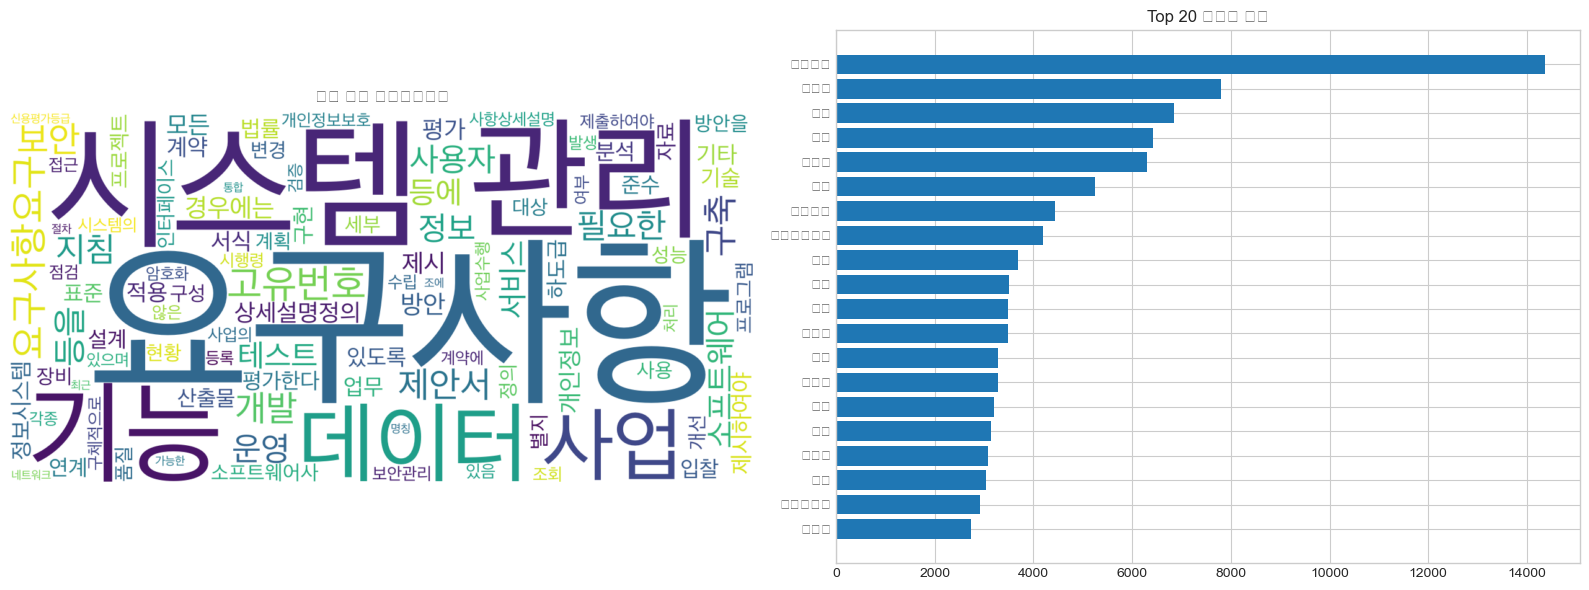

In [48]:
from collections import Counter
from wordcloud import WordCloud

# 전체 텍스트에서 2글자 이상 한글 단어 추출 (간이 토크나이징)
all_text = ' '.join(df_parsed['원본_텍스트'].fillna(''))

# 한글 2~6글자 단어 추출
words = re.findall(r'[가-힣]{2,6}', all_text)

# 불용어 제거 (조사, 어미, 범용 동사 등)
stopwords = {'있는', '하는', '하여', '위한', '대한', '통한', '따른', '관한', '의한',
             '등의', '에서', '으로', '에는', '것을', '수행', '대해', '이를', '것이',
             '해야', '있을', '없는', '한다', '있다', '된다', '않는', '위해',
             '그리고', '또는', '이상', '이하', '경우', '사항', '관련', '포함',
             '필요', '가능', '진행', '내용', '결과', '방법', '활용', '기준',
             '제출', '작성', '확인', '검토', '반영', '제공', '지원', '해당',
             '대하여', '따라', '통해', '위하여', '에게', '부터', '까지',
             '다음', '같은', '것으로', '때문', '이에', '하고', '하며',
             '및', '등', '외', '중', '각', '간', '내', '후', '전'}

filtered = [w for w in words if w not in stopwords]
word_counts = Counter(filtered)

print('=== 상위 30개 키워드 ===')
for word, count in word_counts.most_common(30):
    print(f'  {word}: {count}')

# 워드클라우드
font_path = '/System/Library/Fonts/AppleSDGothicNeo.ttc'
wc = WordCloud(
    font_path=font_path,
    width=1200, height=600,
    background_color='white',
    max_words=100,
    colormap='viridis'
)
wc.generate_from_frequencies(dict(word_counts.most_common(100)))

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

axes[0].imshow(wc, interpolation='bilinear')
axes[0].axis('off')
axes[0].set_title('전체 문서 워드클라우드')

# 상위 20 키워드 바차트
top20 = word_counts.most_common(20)
axes[1].barh([w[0] for w in top20][::-1], [w[1] for w in top20][::-1])
axes[1].set_title('Top 20 키워드 빈도')

plt.tight_layout()
plt.show()

## 13. 상관관계 분석

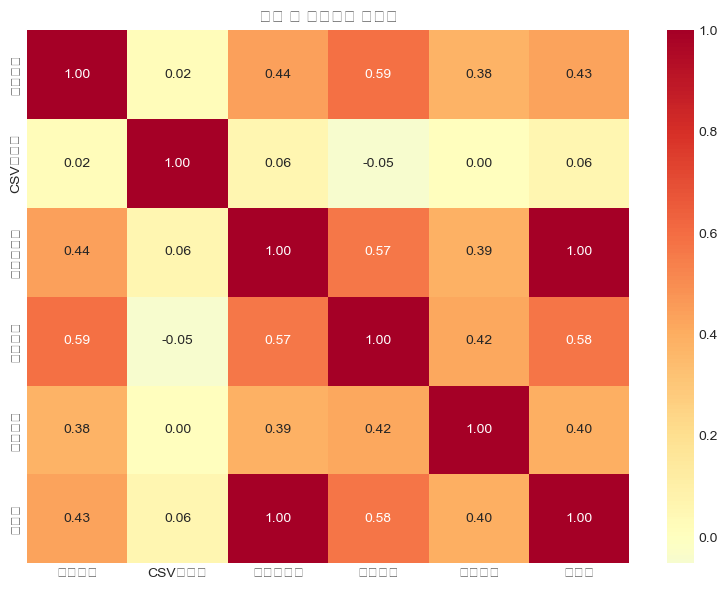

주요 인사이트:
  파일크기 ↔ 원본텍스트: 0.39
  파일크기 ↔ 이미지수: 0.42
  사업금액 ↔ 원본텍스트: 0.44


In [49]:
# 수치형 변수 간 상관관계
df_corr = df_compare.merge(
    df_parsed[['파일명_nfc', '원본_텍스트_길이', '이미지수', '파일크기_KB', '토큰수']],
    on='파일명_nfc', how='left', suffixes=('', '_parsed')
)

corr_cols = ['사업 금액', '텍스트_길이', '원본_텍스트_길이_parsed', '이미지수_parsed', '파일크기_KB', '토큰수']
corr_matrix = df_corr[corr_cols].corr()

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, cmap='RdYlBu_r', center=0,
            fmt='.2f', ax=ax, 
            xticklabels=['사업금액', 'CSV텍스트', '원본텍스트', '이미지수', '파일크기', '토큰수'],
            yticklabels=['사업금액', 'CSV텍스트', '원본텍스트', '이미지수', '파일크기', '토큰수'])
ax.set_title('변수 간 상관관계 히트맵')
plt.tight_layout()
plt.show()

print('주요 인사이트:')
print(f"  파일크기 ↔ 원본텍스트: {corr_matrix.loc['파일크기_KB', '원본_텍스트_길이_parsed']:.2f}")
print(f"  파일크기 ↔ 이미지수: {corr_matrix.loc['파일크기_KB', '이미지수_parsed']:.2f}")
print(f"  사업금액 ↔ 원본텍스트: {corr_matrix.loc['사업 금액', '원본_텍스트_길이_parsed']:.2f}")

## 14. 문장 단위 분석 (청킹 전략 수립용)
문장 길이 분포를 파악하여 최적 청크 크기를 결정합니다.

=== 전체 문장 수: 62,562개 ===

문장 길이(글자) 통계:
count    62562.0
mean       109.0
std        378.0
min          6.0
25%         18.0
50%         40.0
75%         84.0
max      16740.0
Name: 문장_길이, dtype: float64


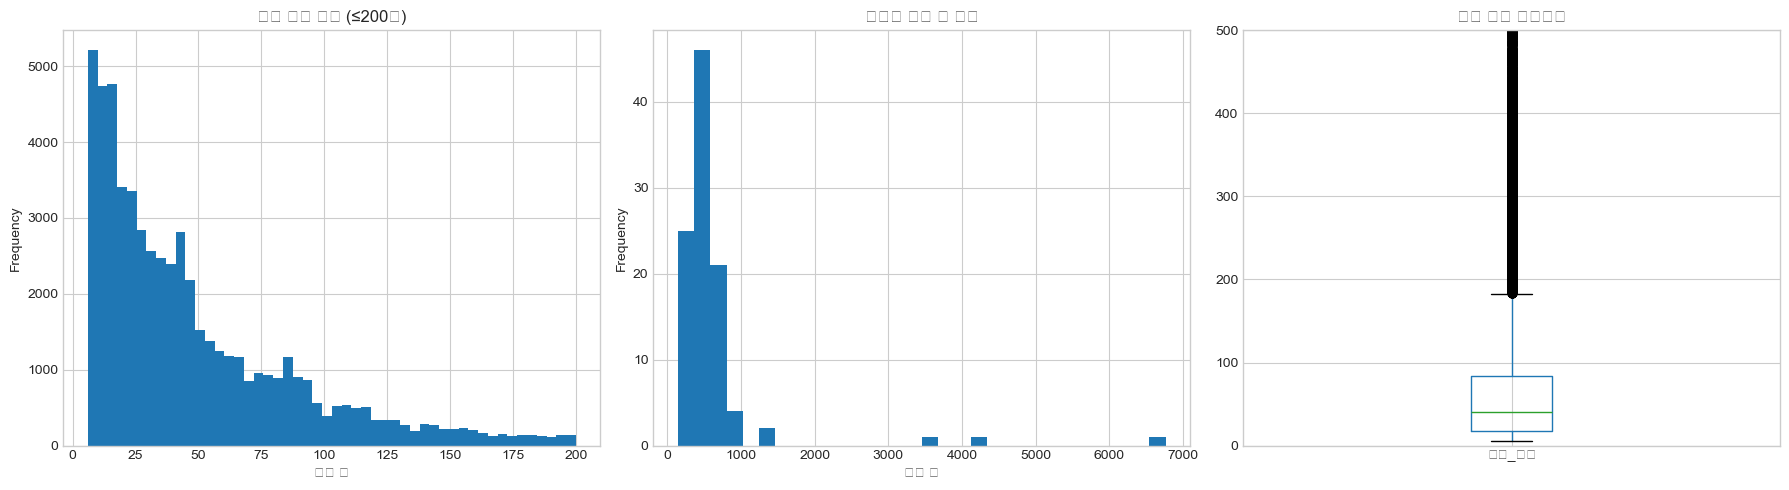


300자 초과 문장: 3674개 (표/목록 데이터일 가능성)

예시:
  [(사)벤처기업협회_2024년 벤처확인종합관리시스템 기능] 09월 中 GrandOpen□ (소요예산) 352,000,000원(부가가치세 포함)□ (계약방식) 제한경쟁입찰(협상에 의한 계약)에 의한 선정*    * (근거) 「국가를 당사자로...
  [(사)벤처기업협회_2024년 벤처확인종합관리시스템 기능] 사업 추진방안1 추진목표추진목표◈ 벤처확인 연계를 통한 복수의결권 및 스톡옵션 시스템 고도화◈ 복수의결권주식, 스톡옵션 업무시스템 구축◈ 스톡옵션 데이터 이관 작업 수행◈ 신청접수...
  [(사)벤처기업협회_2024년 벤처확인종합관리시스템 기능] 10) 준수, 스톡옵션 GrandOpen(미정)주요내용M-1MM+1M+2M+3M+4123412341234123412341234RFP 공고사업추진기술/가격 협상 및 계약착수보고요구분...


In [50]:
# 문장 분리 및 길이 분석
all_sentences = []
for _, row in df_parsed.iterrows():
    text = row['원본_텍스트']
    if not text:
        continue
    # 마침표, 줄바꿈 기준 문장 분리
    sents = re.split(r'[.!?\n]+', text)
    sents = [s.strip() for s in sents if len(s.strip()) > 5]
    for s in sents:
        all_sentences.append({
            '파일명_nfc': row['파일명_nfc'],
            '문장': s,
            '문장_길이': len(s),
            '문장_단어수': len(s.split())
        })

df_sent = pd.DataFrame(all_sentences)

print(f'=== 전체 문장 수: {len(df_sent):,}개 ===')
print(f'\n문장 길이(글자) 통계:')
print(df_sent['문장_길이'].describe().round(0))

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 문장 길이 분포 (200자 이하만)
df_sent[df_sent['문장_길이'] <= 200]['문장_길이'].plot.hist(bins=50, ax=axes[0])
axes[0].set_title('문장 길이 분포 (≤200자)')
axes[0].set_xlabel('글자 수')

# 문장 수 per 문서
sent_per_doc = df_sent.groupby('파일명_nfc').size()
sent_per_doc.plot.hist(bins=30, ax=axes[1])
axes[1].set_title('문서별 문장 수 분포')
axes[1].set_xlabel('문장 수')

# 문장 길이 박스플롯 (이상치 확인)
df_sent.boxplot(column='문장_길이', ax=axes[2])
axes[2].set_title('문장 길이 박스플롯')
axes[2].set_ylim(0, 500)

plt.tight_layout()
plt.show()

# 비정상적으로 긴 문장 (표 데이터일 가능성)
long_sents = df_sent[df_sent['문장_길이'] > 300]
print(f'\n300자 초과 문장: {len(long_sents)}개 (표/목록 데이터일 가능성)')
if len(long_sents) > 0:
    print('\n예시:')
    for _, row in long_sents.head(3).iterrows():
        print(f"  [{row['파일명_nfc'][:30]}] {row['문장'][:100]}...")

## 15. N-gram 분석 (핵심 용어 파악)

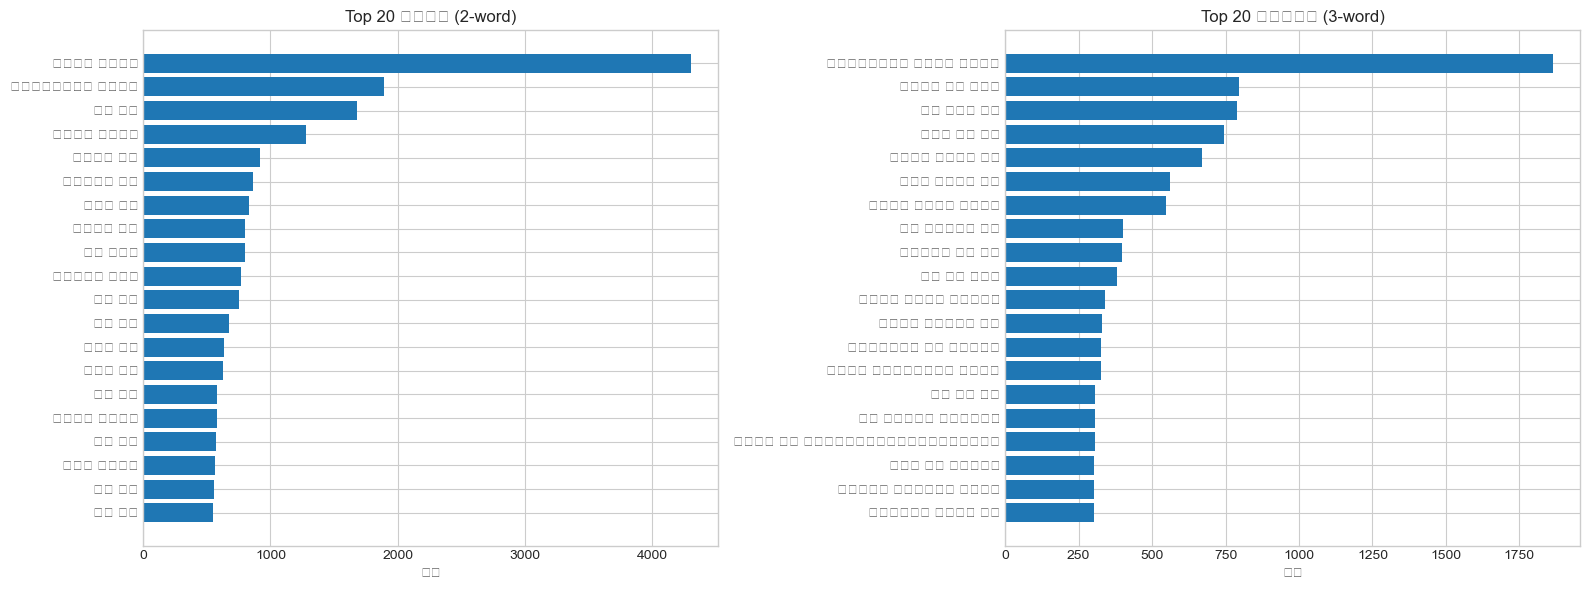

=== RFP 핵심 복합 용어 (바이그램) ===
  고유번호 요구사항: 4303
  요구사항요구사항 고유번호: 1890
  관한 법률: 1680
  요구사항 요구사항: 1282
  요구사항 명칭: 918
  제시하여야 한다: 862
  계약에 관한: 829
  당사자로 하는: 800
  하는 계약에: 800
  소프트웨어 진흥법: 765
  별지 서식: 753
  관한 지침: 671
  협상에 의한: 634
  시스템 구축: 625
  기능 구현: 583

=== RFP 핵심 복합 용어 (트라이그램) ===
  요구사항요구사항 고유번호 요구사항: 1863
  당사자로 하는 계약에: 795
  하는 계약에 관한: 790
  계약에 관한 법률: 746
  고유번호 요구사항 명칭: 670
  국가를 당사자로 하는: 561
  요구사항 고유번호 요구사항: 549
  계약 관리감독에 관한: 400
  관리감독에 관한 지침: 397
  관한 법률 시행령: 382
  행정기관 공공기관 정보시스템: 341
  공공기관 정보시스템 구축: 331
  소프트웨어사업 계약 관리감독에: 326
  분류기능 요구사항요구사항 고유번호: 325
  한다 세부 기술: 306


In [51]:
# 바이그램 / 트라이그램 분석
from itertools import islice

def get_ngrams(text, n):
    words = re.findall(r'[가-힣]{2,}', text)
    return [' '.join(words[i:i+n]) for i in range(len(words) - n + 1)]

all_text_combined = ' '.join(df_parsed['원본_텍스트'].fillna(''))

bigrams = Counter(get_ngrams(all_text_combined, 2))
trigrams = Counter(get_ngrams(all_text_combined, 3))

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# 바이그램 Top 20
bi_top = bigrams.most_common(20)
axes[0].barh([b[0] for b in bi_top][::-1], [b[1] for b in bi_top][::-1])
axes[0].set_title('Top 20 바이그램 (2-word)')
axes[0].set_xlabel('빈도')

# 트라이그램 Top 20
tri_top = trigrams.most_common(20)
axes[1].barh([t[0] for t in tri_top][::-1], [t[1] for t in tri_top][::-1])
axes[1].set_title('Top 20 트라이그램 (3-word)')
axes[1].set_xlabel('빈도')

plt.tight_layout()
plt.show()

print('=== RFP 핵심 복합 용어 (바이그램) ===')
for term, cnt in bi_top[:15]:
    print(f'  {term}: {cnt}')

print('\n=== RFP 핵심 복합 용어 (트라이그램) ===')
for term, cnt in tri_top[:15]:
    print(f'  {term}: {cnt}')

## 16. 발주기관별 텍스트 특성 비교

=== 기관 유형별 문서 수 ===
기관유형
공공기관    42
중앙정부    19
기타      15
지자체     13
대학      11
Name: count, dtype: int64


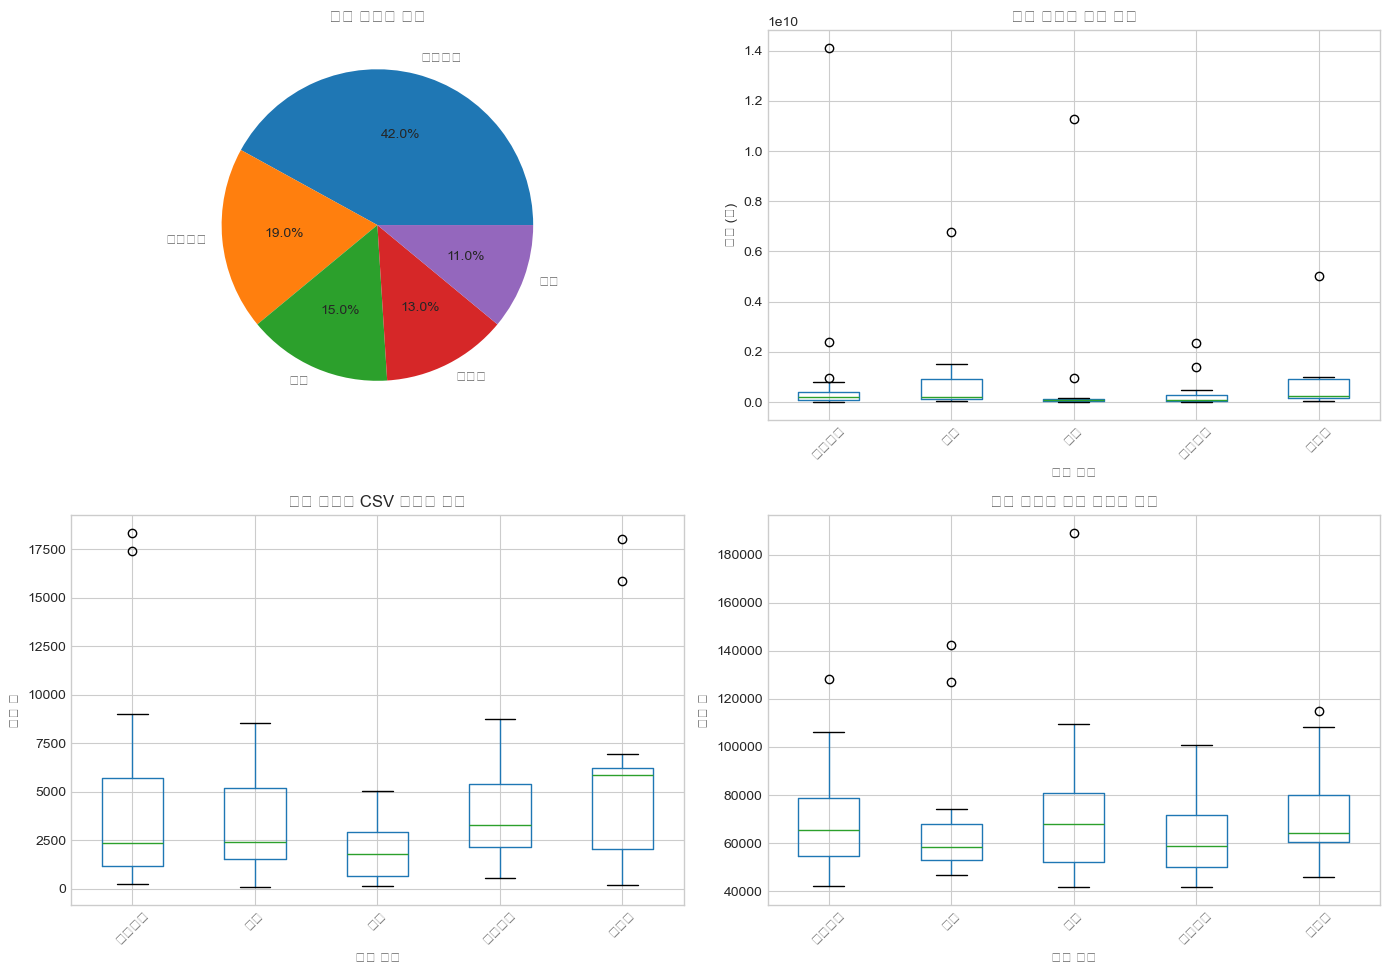


=== 기관유형별 평균 통계 ===
             사업 금액  텍스트_길이  원본_텍스트_길이  이미지수
기관유형                                       
공공기관  6.452976e+08  3871.0    70157.0   6.0
기타    8.851116e+08  3439.0    68182.0  10.0
대학    1.167818e+09  1955.0    77286.0  36.0
중앙정부  3.306923e+08  3864.0    63084.0   6.0
지자체   7.502547e+08  5790.0    72066.0   7.0


In [52]:
# 발주기관별 문서 특성
df_agency = df_compare.copy()

# 기관 유형 분류
def classify_agency(name):
    if any(k in str(name) for k in ['대학', '대학교']):
        return '대학'
    elif any(k in str(name) for k in ['공단', '공사', '진흥원', '연구원', '연구소', '재단']):
        return '공공기관'
    elif any(k in str(name) for k in ['시', '도', '군', '구', '특별시', '광역시']):
        return '지자체'
    elif any(k in str(name) for k in ['부', '처', '청', '원', '위원회']):
        return '중앙정부'
    else:
        return '기타'

df_agency['기관유형'] = df_agency['발주 기관'].apply(classify_agency)

print('=== 기관 유형별 문서 수 ===')
print(df_agency['기관유형'].value_counts())

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 기관유형별 파이차트
df_agency['기관유형'].value_counts().plot.pie(ax=axes[0][0], autopct='%1.1f%%')
axes[0][0].set_title('기관 유형별 분포')
axes[0][0].set_ylabel('')

# 기관유형별 사업금액
df_agency.boxplot(column='사업 금액', by='기관유형', ax=axes[0][1])
axes[0][1].set_title('기관 유형별 사업 금액')
axes[0][1].set_xlabel('기관 유형')
axes[0][1].set_ylabel('금액 (원)')
plt.sca(axes[0][1])
plt.xticks(rotation=45)

# 기관유형별 텍스트 길이 (CSV)
df_agency.boxplot(column='텍스트_길이', by='기관유형', ax=axes[1][0])
axes[1][0].set_title('기관 유형별 CSV 텍스트 길이')
axes[1][0].set_xlabel('기관 유형')
axes[1][0].set_ylabel('글자 수')
plt.sca(axes[1][0])
plt.xticks(rotation=45)

# 기관유형별 원본 텍스트 길이
df_agency.boxplot(column='원본_텍스트_길이', by='기관유형', ax=axes[1][1])
axes[1][1].set_title('기관 유형별 원본 텍스트 길이')
axes[1][1].set_xlabel('기관 유형')
axes[1][1].set_ylabel('글자 수')
plt.sca(axes[1][1])
plt.xticks(rotation=45)

plt.suptitle('')
plt.tight_layout()
plt.show()

print('\n=== 기관유형별 평균 통계 ===')
print(df_agency.groupby('기관유형').agg({
    '사업 금액': 'mean',
    '텍스트_길이': 'mean',
    '원본_텍스트_길이': 'mean',
    '이미지수': 'mean'
}).round(0).to_string())

## 17. 문서 유사도 & 클러스터링 (TF-IDF 기반)
문서 간 유사도를 분석하여 RAG 검색 시 혼동될 수 있는 문서 쌍을 파악합니다.

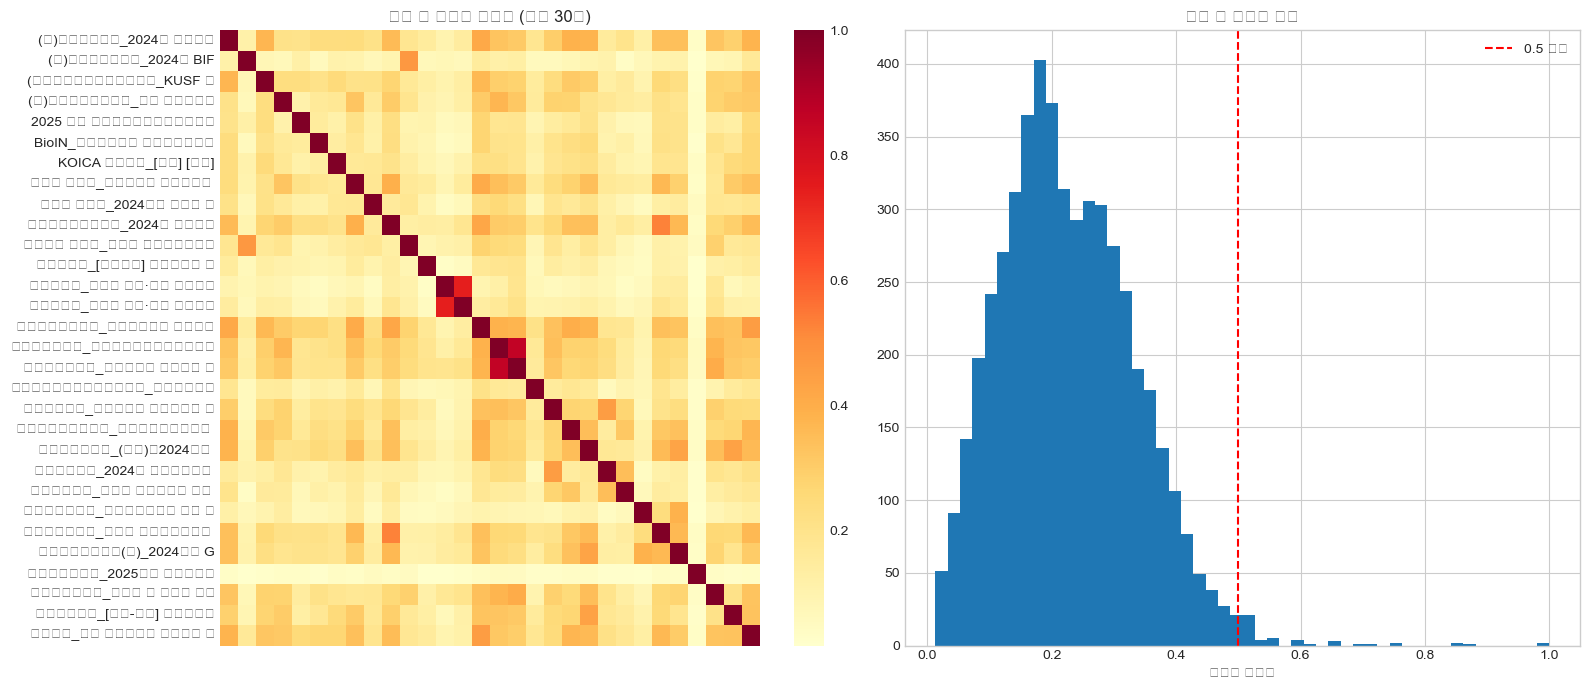

=== 가장 유사한 문서 쌍 Top 5 (RAG 검색 시 혼동 주의) ===
  유사도 1.000: 국가과학기술지식정보서비스_통합정보시스템 고도화 용역.hwp ↔ 한국한의학연구원_통합정보시스템 고도화 용역.hwp
  유사도 1.000: BioIN_의료기기산업 종합정보시스템(정보관리기관) 기능개선 사 ↔ 한국보건산업진흥원_의료기기산업 종합정보시스템(정보관리기관) 기능
  유사도 0.879: 한국생산기술연구원_2세대 전자조달시스템  기반구축사업.hwp ↔ 한국생산기술연구원_EIP3.0 고압가스 안전관리 시스템 구축 용
  유사도 0.860: 광주과학기술원_실시간통합연구비관리시스템(RCMS)  연계 모듈  ↔ 광주과학기술원_학사시스템 기능개선 사업.hwp
  유사도 0.854: 축산물품질평가원_꿀 품질평가 전산시스템 기능개선 사업.hwp ↔ 축산물품질평가원_축산물이력관리시스템 개선(정보화 사업).hwp


In [53]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.cluster import KMeans

# TF-IDF 벡터화 (원본 텍스트가 있는 문서만)
valid_docs = df_parsed[df_parsed['원본_텍스트_길이'] > 0].copy()
texts = valid_docs['원본_텍스트'].tolist()
names = valid_docs['파일명_nfc'].tolist()

tfidf = TfidfVectorizer(
    analyzer='word',
    token_pattern=r'[가-힣]{2,}',
    max_features=5000,
    max_df=0.9,
    min_df=2
)
tfidf_matrix = tfidf.fit_transform(texts)

# 코사인 유사도
cos_sim = cosine_similarity(tfidf_matrix)

# 유사도 히트맵 (상위 30개 문서만)
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

short_names = [n[:20] for n in names[:30]]
sns.heatmap(cos_sim[:30, :30], ax=axes[0], cmap='YlOrRd',
            xticklabels=False, yticklabels=short_names)
axes[0].set_title('문서 간 코사인 유사도 (상위 30개)')

# 유사도 분포
upper_tri = cos_sim[np.triu_indices_from(cos_sim, k=1)]
axes[1].hist(upper_tri, bins=50)
axes[1].set_title('문서 쌍 유사도 분포')
axes[1].set_xlabel('코사인 유사도')
axes[1].axvline(x=0.5, color='r', linestyle='--', label='0.5 기준')
axes[1].legend()

plt.tight_layout()
plt.show()

# 가장 유사한 문서 쌍 Top 5
pairs = []
for i in range(len(cos_sim)):
    for j in range(i+1, len(cos_sim)):
        pairs.append((names[i], names[j], cos_sim[i][j]))
pairs.sort(key=lambda x: x[2], reverse=True)

print('=== 가장 유사한 문서 쌍 Top 5 (RAG 검색 시 혼동 주의) ===')
for a, b, score in pairs[:5]:
    print(f'  유사도 {score:.3f}: {a[:35]} ↔ {b[:35]}')

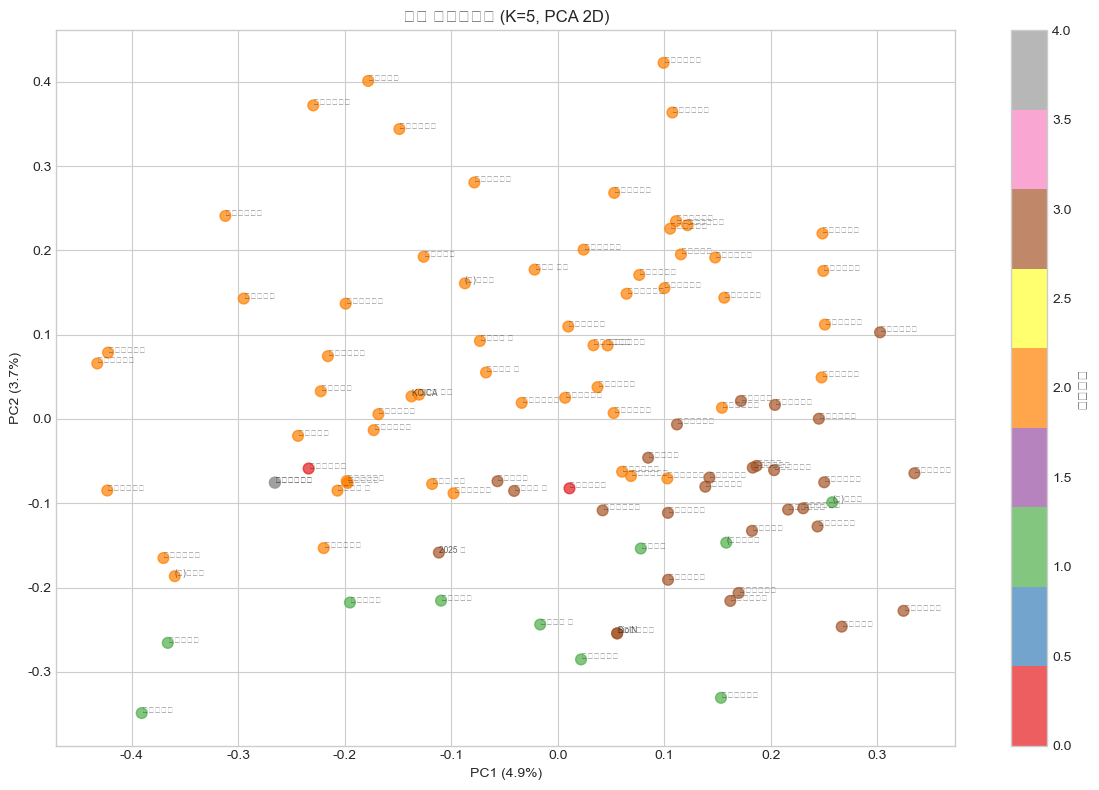

=== 클러스터별 주요 키워드 ===

  클러스터 0 (2개 문서): 갖추거나, 근무한, 분야에서, 사람, 경력을, 일정기간, 자로서, 해당기술, 가진, 졸업한

  클러스터 1 (10개 문서): 고유번호, 조회, 신청, 학사, 학생, 요구사항요구사항, 포털, 분류기능, 인증, 청구

  클러스터 2 (58개 문서): 고유번호, 하도급, 요구사항요구사항, 별지, 평가한다, 수탁자, 별표, 붙임, 공동수급체, 적정성

  클러스터 3 (29개 문서): 요구사항요구사항, 고유번호, 평가한다, 분류기능, 모바일, 제품, 분류, 행정안전부, 명칭, 암호화

  클러스터 4 (2개 문서): 임상연구, 산출물요구사항번호, 기관생명윤리, 동물실험계획, 동물실험, 연구노트, 전자결재, 요구사항번호, 개발에, 적정성


In [54]:
# K-Means 클러스터링
from sklearn.decomposition import PCA

n_clusters = 5
kmeans = KMeans(n_clusters=n_clusters, random_state=42, n_init=10)
clusters = kmeans.fit_predict(tfidf_matrix)

# PCA 2D 시각화
pca = PCA(n_components=2)
coords = pca.fit_transform(tfidf_matrix.toarray())

fig, ax = plt.subplots(figsize=(12, 8))
scatter = ax.scatter(coords[:, 0], coords[:, 1], c=clusters, cmap='Set1', alpha=0.7, s=60)
ax.set_title(f'문서 클러스터링 (K={n_clusters}, PCA 2D)')
ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%})')
ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%})')
plt.colorbar(scatter, label='클러스터')

# 각 점에 짧은 레이블
for i, name in enumerate(names):
    short = name.split('_')[0][:6] if '_' in name else name[:6]
    ax.annotate(short, (coords[i, 0], coords[i, 1]), fontsize=6, alpha=0.7)

plt.tight_layout()
plt.show()

# 클러스터별 주요 키워드
print('=== 클러스터별 주요 키워드 ===')
feature_names = tfidf.get_feature_names_out()
for c in range(n_clusters):
    cluster_center = kmeans.cluster_centers_[c]
    top_indices = cluster_center.argsort()[-10:][::-1]
    top_words = [feature_names[i] for i in top_indices]
    doc_count = (clusters == c).sum()
    print(f'\n  클러스터 {c} ({doc_count}개 문서): {", ".join(top_words)}')

## 18. 텍스트 전처리 전/후 비교
RAG에 넣기 전 클리닝 효과를 미리 확인합니다.

In [55]:
def clean_text(text):
    """RFP 텍스트 전처리"""
    if not text:
        return ''
    # 연속 공백 → 단일 공백
    text = re.sub(r' {2,}', ' ', text)
    # 연속 줄바꿈 → 최대 2개
    text = re.sub(r'\n{3,}', '\n\n', text)
    # 연속 탭 정리
    text = re.sub(r'\t{2,}', '\t', text)
    # 페이지 번호 패턴 제거
    text = re.sub(r'\n\s*-?\s*\d+\s*-?\s*\n', '\n', text)
    # 앞뒤 공백 정리
    text = '\n'.join(line.strip() for line in text.split('\n'))
    # 빈 줄 연속 제거
    text = re.sub(r'\n{3,}', '\n\n', text)
    return text.strip()

# 전처리 전/후 비교 (3개 샘플)
samples = df_parsed[df_parsed['원본_텍스트_길이'] > 1000].sample(3, random_state=42)

for _, row in samples.iterrows():
    raw = row['원본_텍스트']
    cleaned = clean_text(raw)
    
    print(f"=== {row['파일명_nfc'][:50]} ===")
    print(f"  전처리 전: {len(raw):,}자 → 후: {len(cleaned):,}자 ({(1-len(cleaned)/len(raw))*100:.1f}% 감소)")
    print(f"\n  [전처리 전 앞 200자]")
    print(f"  {raw[:200]}")
    print(f"\n  [전처리 후 앞 200자]")
    print(f"  {cleaned[:200]}")
    print()

# 전체 전처리 효과
total_before = df_parsed['원본_텍스트_길이'].sum()
total_after = sum(len(clean_text(t)) for t in df_parsed['원본_텍스트'])
print(f'=== 전체 전처리 효과 ===')
print(f'  전처리 전 총 글자 수: {total_before:,}')
print(f'  전처리 후 총 글자 수: {total_after:,}')
print(f'  감소율: {(1-total_after/total_before)*100:.1f}%')

=== 한국수자원공사_수도사업장 통합 사고분석솔루션 시범구축 용역.hwp ===
  전처리 전: 55,582자 → 후: 54,358자 (2.2% 감소)

  [전처리 전 앞 200자]
  수도사업장 통합 사고분석솔루션 시범구축 용역제안요청서(RFP : Request For Proposal)2024. 5.유역·지방상수도처- 목   차 -1. 제안공모 개요    1.1 일반사항    1.2 제안참가 안내    1.3 제안요구 사항    1.4 제안서 작성요령    1.5 기타사항2. 제안자를 위한 정보    2.1 K-water 일반정보    

  [전처리 후 앞 200자]
  수도사업장 통합 사고분석솔루션 시범구축 용역제안요청서(RFP : Request For Proposal)2024. 5.유역·지방상수도처- 목 차 -1. 제안공모 개요 1.1 일반사항 1.2 제안참가 안내 1.3 제안요구 사항 1.4 제안서 작성요령 1.5 기타사항2. 제안자를 위한 정보 2.1 K-water 일반정보 2.2 대상시스템 현황3. 제안요청 내용 

=== 재단법인 한국장애인문화예술원_2024년 장애인문화예술정보시스템 이음.hwp ===
  전처리 전: 47,195자 → 후: 45,500자 (3.6% 감소)

  [전처리 전 앞 200자]
  2024년 장애인문화예술정보시스템이음온라인 운영 용역[제 안 요 청 서]2024. 2. 【목 차】Ⅰ. 사업개요 	 1Ⅱ. 제안요청내용	 2Ⅲ. 제안 안내사항	 39Ⅳ. 제안서 제출 및 작성	 44 Ⅰ. 사업개요 1. 용역개요  ㅇ 사 업 명 : 2024년 장애인문화예술정보시스템 이음온라인 운영 ㅇ 사업기간 : 계약체결일 ~ 2024. 12. 31.  ㅇ 입

  [전처리 후 앞 200자]
  2024년 장애인문화예술정보시스템이음온라인 운영 용역[제 안 요 청 서]2024. 2. 【목 차】Ⅰ. 사업개요 	 1Ⅱ. 제안요청내용	 2Ⅲ. 제안 안내사항	 39Ⅳ. 제안서 제출 및 작성	 44 Ⅰ. 사업개요 1. 용역개요 ㅇ 사 업 명 : 2024년

## 19. PDF 테이블 추출 예시

In [56]:
# PDF 테이블 추출 예시
pdf_files = [f for f in os.listdir('files/') if f.lower().endswith('.pdf')]

total_tables = 0
for pf in pdf_files:
    path = os.path.join('files/', pf)
    nfc = unicodedata.normalize('NFC', pf)
    try:
        with pdfplumber.open(path) as pdf:
            doc_tables = 0
            for page in pdf.pages:
                tables = page.extract_tables()
                doc_tables += len(tables)
            total_tables += doc_tables
            print(f'{nfc[:50]} | 테이블 {doc_tables}개')
            
            # 첫 번째 테이블 예시 출력
            if doc_tables > 0:
                for page in pdf.pages:
                    tables = page.extract_tables()
                    if tables:
                        print(f'\n  [테이블 예시 - 처음 5행]')
                        table_df = pd.DataFrame(tables[0][1:], columns=tables[0][0])
                        print(table_df.head().to_string(index=False))
                        break
    except Exception as e:
        print(f'{nfc[:50]} | 오류: {e}')

print(f'\n총 PDF 테이블 수: {total_tables}개')

기초과학연구원_2025년도 중이온가속기용 극저온시스템 운전 용역.pdf | 테이블 67개

  [테이블 예시 - 처음 5행]
 문서번호            -
 개정번호            0
발 행 일 2024. 10. 30
고려대학교_차세대 포털·학사 정보시스템 구축사업.pdf | 테이블 420개

  [테이블 예시 - 처음 5행]
Empty DataFrame
Columns: [, 고려대학교 차세대 포털·학사 정보시스템 구축 사업, ]
Index: []
서울특별시_2024년 지도정보 플랫폼 및 전문활용 연계 시스템 고도화 용.pdf | 테이블 169개

  [테이블 예시 - 처음 5행]
사 업 명 2024년 지도정보 플랫폼 및 전문활용\n연계 시스템 고도화 용역
 주관기관                                서울특별시
서울시립대학교_[사전공개] 학업성취도 다차원 종단분석 통합시스템 1차.pdf | 테이블 187개

  [테이블 예시 - 처음 5행]
사 업 명 학업성취도 다차원 종단분석 통합시스템 1차 고도화
 주관기관         서 울 시 립 대 학 교 입 학 처

총 PDF 테이블 수: 843개


### 20-1. DOCX 테이블 추출 예시

In [57]:
# DOCX 테이블 상세 추출
docx_files = [f for f in os.listdir('files/') if f.lower().endswith('.docx')]

for df_name in docx_files:
    actual_path = os.path.join('files/', df_name)
    nfc = unicodedata.normalize('NFC', df_name)
    doc = python_docx.Document(actual_path)
    
    print(f'=== {nfc} ===')
    print(f'본문 단락: {len(doc.paragraphs)}개')
    print(f'표: {len(doc.tables)}개')
    
    # 이미지 수
    img_count = sum(1 for rel in doc.part.rels.values() if "image" in rel.reltype)
    print(f'이미지: {img_count}개')
    
    # 표 예시 (처음 3개)
    for t_idx, table in enumerate(doc.tables[:3]):
        print(f'\n  [표 {t_idx+1}] ({len(table.rows)}행 x {len(table.columns)}열)')
        rows_data = []
        for row in table.rows[:5]:  # 앞 5행만
            cells = [cell.text.strip()[:30] for cell in row.cells]
            rows_data.append(cells)
        
        try:
            tdf = pd.DataFrame(rows_data)
            print(tdf.to_string(index=False, header=False))
        except:
            for r in rows_data:
                print(f'    {" | ".join(r)}')
    
    if len(doc.tables) > 3:
        print(f'\n  ... 나머지 {len(doc.tables) - 3}개 표 생략')

=== 고려대학교_차세대 포털·학사 정보시스템 구축사업.docx ===
본문 단락: 787개
표: 105개
이미지: 5개

  [표 1] (1행 x 1열)
※ 본 자료는 제안내용의 설명을 위한 배포자료로, 이외

  [표 2] (1행 x 1열)
고려대학교 차세대 포털·학사 정보시스템 구축 사업

  [표 3] (4행 x 3열)
  정보시스템                           주요내용                   비고
  포털시스템 ­ 통합로그인, 통합/지능형 검색, 마이페이지, 공지/            개인화 \n서비스
 모바일서비스 ­ 통합로그인, 통합/지능형 검색, 마이페이지, 공지/ 기존 호잇 \n통합,  \n하이브리드
학사행정시스템 ­ 기준정보 관리, 권한관리, 사용자 관리 등 공통 관          학사전반 \n통합관리

  ... 나머지 102개 표 생략


## 20. 종합 요약 및 RAG 시스템 설계 시사점

In [58]:
print('=' * 60)
print('         EDA 종합 요약 및 RAG 설계 시사점')
print('=' * 60)

print(f'''
[데이터 개요]
  - 총 문서: 100개 (CSV 기준) / 101개 파일 (docx 1개 추가)
  - 파일형식: HWP {(df["파일형식"]=="hwp").sum()}개, PDF {(df["파일형식"]=="pdf").sum()}개
  - 발주기관: {df["발주 기관"].nunique()}개 기관

[텍스트 현황 - 핵심 발견]
  - CSV 텍스트 평균: {df["텍스트_길이"].mean():.0f}자 (원본의 ~6%만 포함)
  - 원본 파싱 텍스트 평균: {df_parsed["원본_텍스트_길이"].mean():.0f}자
  - 원본 토큰 수 평균: {df_parsed["토큰수"].mean():.0f} 토큰
  - 총 토큰: {df_parsed["토큰수"].sum():,} 토큰
  ⚠ CSV 텍스트는 원본 대비 약 94% 손실 → 반드시 원본 파싱 사용

[문서 구조]
  - RFP 공통 섹션 (사업개요, 요구사항, 평가기준 등) 대부분 존재
  - 의미 단위 청킹 시 섹션 헤더 기반 분할 가능

[이미지/테이블]
  - 이미지 포함 문서: {(df_parsed["이미지수"] > 0).sum()}/{len(df_parsed)}개
  - 평균 이미지 수: {df_parsed["이미지수"].mean():.1f}개
  ⚠ 이미지 속 텍스트(표, 도표)는 별도 OCR 필요

[클러스터링]
  - TF-IDF 기반 5개 클러스터로 문서 그룹핑 가능
  - 유사 문서 쌍 존재 → 메타데이터 필터링 필수

[RAG 설계 권장사항]
  1. 문서 로딩: CSV가 아닌 원본 HWP(olefile)/PDF(pdfplumber) 직접 파싱
  2. 전처리: 연속 공백/줄바꿈 정리, 페이지 번호 제거
  3. 청킹: 512~1024 토큰 + 25% 오버랩 추천 (문서 길이 편차 크므로)
  4. 메타데이터 필터링: 사업명, 발주기관, 사업금액, 기관유형
  5. 결측치: 공고번호({df["공고 번호"].isna().sum()}건), 입찰참여시작일({df["입찰 참여 시작일"].isna().sum()}건) 처리 필요
  6. 임베딩: text-embedding-3-small 토큰 제한(8191) 초과 문서 반드시 청킹
  7. 유사 문서 구분: 메타데이터 기반 필터링 + 문서별 고유 키워드 활용
''')

print('=' * 60)

         EDA 종합 요약 및 RAG 설계 시사점

[데이터 개요]
  - 총 문서: 100개 (CSV 기준) / 101개 파일 (docx 1개 추가)
  - 파일형식: HWP 96개, PDF 4개
  - 발주기관: 87개 기관

[텍스트 현황 - 핵심 발견]
  - CSV 텍스트 평균: 3844자 (원본의 ~6%만 포함)
  - 원본 파싱 텍스트 평균: 69397자
  - 원본 토큰 수 평균: 41435 토큰
  - 총 토큰: 4,184,924 토큰
  ⚠ CSV 텍스트는 원본 대비 약 94% 손실 → 반드시 원본 파싱 사용

[문서 구조]
  - RFP 공통 섹션 (사업개요, 요구사항, 평가기준 등) 대부분 존재
  - 의미 단위 청킹 시 섹션 헤더 기반 분할 가능

[이미지/테이블]
  - 이미지 포함 문서: 100/101개
  - 평균 이미지 수: 10.0개
  ⚠ 이미지 속 텍스트(표, 도표)는 별도 OCR 필요

[클러스터링]
  - TF-IDF 기반 5개 클러스터로 문서 그룹핑 가능
  - 유사 문서 쌍 존재 → 메타데이터 필터링 필수

[RAG 설계 권장사항]
  1. 문서 로딩: CSV가 아닌 원본 HWP(olefile)/PDF(pdfplumber) 직접 파싱
  2. 전처리: 연속 공백/줄바꿈 정리, 페이지 번호 제거
  3. 청킹: 512~1024 토큰 + 25% 오버랩 추천 (문서 길이 편차 크므로)
  4. 메타데이터 필터링: 사업명, 발주기관, 사업금액, 기관유형
  5. 결측치: 공고번호(18건), 입찰참여시작일(26건) 처리 필요
  6. 임베딩: text-embedding-3-small 토큰 제한(8191) 초과 문서 반드시 청킹
  7. 유사 문서 구분: 메타데이터 기반 필터링 + 문서별 고유 키워드 활용

